In [1]:
#+++ версия 2025.04.14 tg: Цифриум, команда 2 Машинисты, @codeup1054, @Kimutogo,@Eques8, @serin_1995, @saturnian1, @tyuop077
from importlib import reload
import sys, os 
import ipynbname


current_dir = os.getcwd()

for i in ['utils_log','datetime','glob']:
    if i in sys.modules: del  sys.modules[i] 
    exec (f'from {i} import *')  
    
    
tm()

i = 0
for k in dir(ps):
    if ('_' not in k) and isinstance(getattr(ps, k), str) :
        print (f"{getattr(ps, k)}{k:^9}{ps._} ", end="")
        if (i := i+1)%10 == 0 : print("")

dfr = dfr if 'dfr' in vars() else {}

print ("\n")

NB_PATH_NAME = ipynbname.path().name
LOG_SHEET_NAME = NB_PATH_NAME

tg(f"🧠 Start | {LOG_SHEET_NAME} ", sheet_name=LOG_SHEET_NAME)

tm('>>>')   

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'



 *** Start at: 08:28:17 2025-04-27  ****************************************
  BBLUE     BDRED     BGOLD     BGRAY    BGREEN    BLBLUE    BLCYAN    BLGRAY    BLGREEN   BLILAC   
 BLLBLUE  BLMAGENTA BLORANGE    BLRED     BLUE       BLY    BLYELLOW  BMAGENTA    BOLD     BORANGE  
  BRED     BWHITE      BY      BYELLOW    CYAN    DARKCYAN      E        END       ERR      GOLD    
  GRAY      GREEN     LBLUE     LGRAY    LGREEN   LMAGENTA    LRED     MAGENTA   ORANGE    PURPLE   
   RED        T       TOTAL   UNDERLINE   WHITE       Y      YELLOW      err    

  0:00:02.619  ₀⡄₀₀⡄₀₂.₆₁₉ >>>


datetime.datetime(2025, 4, 27, 8, 28, 20, 448525)

⚠️ Ошибка записи в Google Sheet: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


### 00. поиск файлов

In [4]:
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'


In [20]:
import glob
keyframes_mask = r'lectures_2025\Общественное движение в России 2четверь XIX в_01\keyframes\*'
keyframes = glob.glob(keyframes_mask)
keyframes

['lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_01.jpg',
 'lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_02.jpg',
 'lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_03.jpg',
 'lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_04.jpg',
 'lectures_2025\\Общественное движение в России 2четверь XIX в_01\\keyframes\\keyframe_05.jpg']

### 01. распознавание слайда без разбиения на блоки 

Такого распознавания вполне достаточно чтобы пождмешать слова в промпт

In [2]:
def gradient_color(value, text):
    """
    Подсвечивает текст цветом в зависимости от значения от -10 до 10.
    -10 — красный, 0 — жёлтый, 10 — зелёный.
    """
    # Ограничим значение диапазоном [-10, 10]
    value = max(min(value, 10), -10)

    # Преобразуем значение к [0, 1] (для градиента)
    normalized = (value + 10) / 20

    # Расчёт RGB: от (255, 0, 0) -> (255, 255, 0) -> (0, 255, 0)
    if normalized < 0.5:
        # Красный → Жёлтый
        r = 255
        g = int(255 * (normalized * 2))
        b = 0
    else:
        # Жёлтый → Зелёный
        r = int(255 * (1 - (normalized - 0.5) * 2))
        g = 255
        b = 0

    # ANSI-код 24-bit цвета
    return f"\033[38;2;{r};{g};{b}m{text}\033[0m"


def gradient_bg(value, text):
    """
    Подсвечивает фон текста цветом:
    - от -10 (красный) → 0 (белый) → +10 (синий)
    """
    value = max(min(value, 10), -10)  # ограничение
    r = g = b = 255  # старт с белого

    if value < 0:
        # от -10 до 0 → красный к белому
        factor = (value + 10) / 10  # от 0 до 1
        r = 255
        g = int(255 * factor)
        b = int(255 * factor)
    elif value > 0:
        # от 0 до 10 → белый к синему
        factor = (10 - value) / 10  # от 1 до 0
        r = 100 +  int(155 * factor)
        g = 180 + int(75 * factor)
        b = 255

    return f"\033[48;2;{r};{g};{b}m{text}\033[0m"



for i in range(-15, 15):
    print(gradient_bg(i, f" {i:+7} "), end=" ")
print()

for i in range(-15, 15):
    print(gradient_color(i, f"{i:+3} → цветовой градиент"))

     -15       -14       -13       -12       -11       -10        -9        -8        -7        -6        -5        -4        -3        -2        -1        +0        +1        +2        +3        +4        +5        +6        +7        +8        +9       +10       +11       +12       +13       +14  
-15 → цветовой градиент
-14 → цветовой градиент
-13 → цветовой градиент
-12 → цветовой градиент
-11 → цветовой градиент
-10 → цветовой градиент
 -9 → цветовой градиент
 -8 → цветовой градиент
 -7 → цветовой градиент
 -6 → цветовой градиент
 -5 → цветовой градиент
 -4 → цветовой градиент
 -3 → цветовой градиент
 -2 → цветовой градиент
 -1 → цветовой градиент
 +0 → цветовой градиент
 +1 → цветовой градиент
 +2 → цветовой градиент
 +3 → цветовой градиент
 +4 → цветовой градиент
 +5 → цветовой градиент
 +6 → цветовой градиент
 +7 → цветовой градиент
 +8 → цветовой градиент
 +9 → цветовой градиент
+10 → цветовой градиент
+11 → цветовой градиент
+12 → цветовой градиент
+13 → цветовой градиент
+14

In [120]:
print(best_text.replace("\n"," "))


Общественные движения во второй четверти ХИХ в.  |  консервативное  Основные идеи:  Идеолог консерватизма — С.С. Уваров. Разработал «Теорию официальной народности»:  _ С.С. Уваров  Самодержавие       Православие  Народность     | Самодержавие — это основа жизни русского общества |        Православие — это ориентация человека на общественный интерес, общее благо и справедливость              | Народность выражала единство объединённого вокруг царя народа | |    


  0:00:08.901  ₀⡄₀₄⡄₃₃.₂₈₇ 🚩 Найдено файлов: 29

🔎 Обработка: keyframe_04.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
351 351 351 351 351 351 351 351 351 351 351 353 349 354 301 301 301 300 352 352 355 356 356 301 alpha=0.80
351 351 351 351 351 356 349 348 354 352 355 301 348 352 352 352 355 356 301 301 353 300 300 351 alpha=0.87
353 348 350 354 301 301 301 356 355 352 352 355 355 356 301 355 353 300 300 336 351 350 351 351 alpha=0.94
355 301 356 354 352 352 352 355 356 356 301 355 353 300 300 336 351 351 351 351 351 351 350 349 alpha=1.01
352 352 355 355 356 355 301 355 353 300 300 336 351 351 351 351 351 351 351 350 344 344 344 358 alpha=1.08
356 355 355 355 353 300 300 336 351 351 351 351 351 351 351 351 350 346 345 344 344 351 360 360 alpha=1.15
353 300 300 351 351 351 351 351 351 351 351 351 350 345 345 344 355 361 363 361 

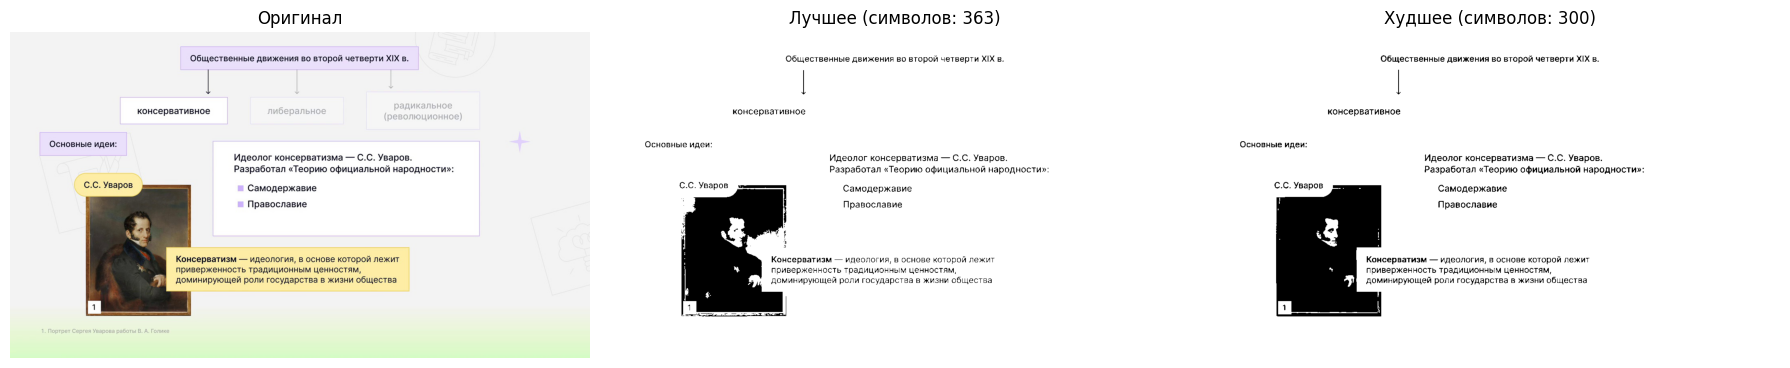

"Лучший текст (символов: 363) α: 1.22, β: 94","Худший текст (символов: 300) α: 0.80, β: 91"
"Общественные движения во второй четверти ХХ в. | консервативное Основные идеи: Идеолог консерватизма — С.С. Уваров. Разработал «Теорию официальной народности»: С.С. Уваров Самодержавие Православие Г} й Консерватизм — идеология, в основе которой лежит приверженность традиционным ценностям, доминирующей роли государства в жизни общества","Общественные движения во второй четверти ХХ в. | консервативное Основные идеи: Идеолог консерватизма — С.С. Уваров. Разработал «Теорию официальной народности»: С.С. Уваров . Самодержавие Православие Консерватизм — идеология, в основе которой лежит приверженность традиционным ценностям,"


  0:01:19.876  ₀⡄₀₅⡄₅₃.₁₆₄ keyframe_04.jpg обработан

🔎 Обработка: keyframe_08.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
426 426 426 426 426 426 426 426 426 426 426 426 426 426 424 424 426 426 426 426 426 425 425 425 alpha=0.80
426 426 426 426 426 426 426 426 426 425 424 426 426 426 426 426 425 426 425 425 425 425 425 425 alpha=0.87
426 426 426 426 424 424 426 426 426 426 425 426 425 425 425 425 425 425 425 425 425 425 408 425 alpha=0.94
424 426 426 426 426 426 426 425 425 425 425 425 425 425 425 425 425 425 425 425 425 425 425 425 alpha=1.01
426 426 426 425 425 425 425 427 427 425 425 425 425 425 408 425 425 425 425 425 425 425 425 408 alpha=1.08
426 425 425 427 425 425 425 425 425 425 425 425 425 425 425 425 425 425 425 425 408 408 408 425 alpha=1.15
425 425 425 425 425 425 425 408 425 424 425 425 425 425 425 425 425 408 408

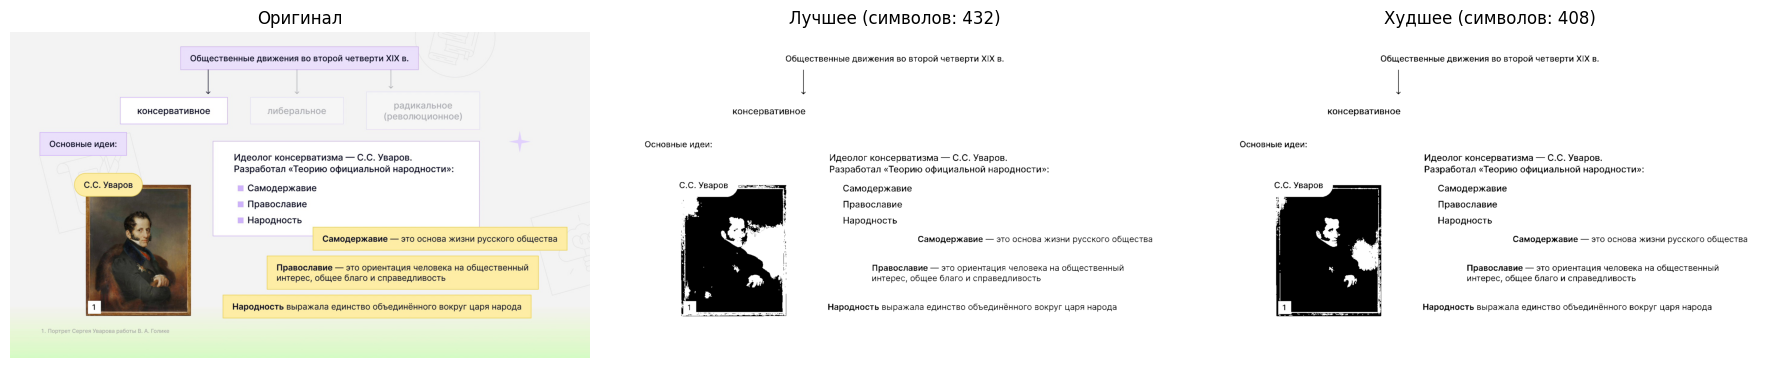

"Лучший текст (символов: 432) α: 1.29, β: 103","Худший текст (символов: 408) α: 0.94, β: 106"
"Общественные движения во второй четверти ХХ в. | консервативное Основные идеи: Идеолог консерватизма — С.С. Уваров. Разработал «Теорию официальной народности»: С.С. Уваров == ела Самодержавие Православие Народность Самодержавие — это основа жизни русского общества Православие — это ориентация человека на общественный интерес, общее благо и справедливость Народность выражала единство объединённого вокруг царя народа","Общественные движения во второй четверти ХХ в. | консервативное Основные идеи: Идеолог консерватизма — С.С. Уваров. Разработал «Теорию официальной народности»: Самодержавие Православие Народность Самодержавие — это основа жизни русского общества Православие — это ориентация человека на общественный интерес, общее благо и справедливость Народность выражала единство объединённого вокруг царя народа"


  0:01:48.687  ₀⡄₀₇⡄₄₁.₈₅₁ keyframe_08.jpg обработан

🔎 Обработка: keyframe_10.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
162 162 162 162 162 162 162 162 178 178 178 178 178 178 178 178 178 178 180 185 185 185 185 184 alpha=0.80
162 162 162 178 178 178 178 178 178 178 178 178 178 180 185 185 185 184 185 184 184 184 185 186 alpha=0.87
162 178 178 178 178 178 178 178 180 185 185 184 184 184 184 184 184 184 184 187 188 189 184 163 alpha=0.94
178 178 178 180 185 185 185 185 184 184 184 186 184 184 186 187 188 188 184 185 184 184 185 187 alpha=1.01
185 185 185 185 184 184 184 186 186 184 187 187 188 188 184 185 163 184 184 187 186 185 186 185 alpha=1.08
184 185 184 184 184 184 186 187 187 190 184 184 184 184 184 185 187 187 185 188 188 187 188 178 alpha=1.15
184 184 186 187 187 190 185 184 185 184 184 184 187 188 187 186 186 184 185

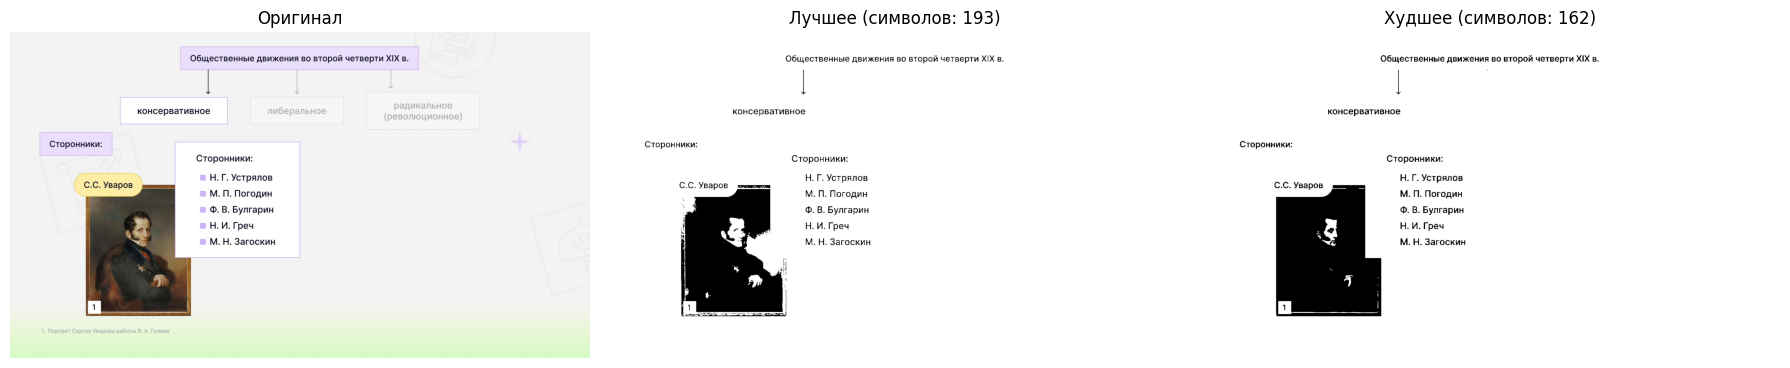

"Лучший текст (символов: 193) α: 1.57, β: 52","Худший текст (символов: 162) α: 0.80, β: 43"
Общественные движения во второй четверти ХХ в. | консервативное Сторонники: Сторонники: Н. Г. Устрялов С.С. Уваров зеезаежекяи М. П. Погодин Ф. В. Булгарин Н. И. Греч М. Н. Загоскин,Общественные движения во второй четверти ХИХ в. | консервативное Сторонники: Сторонники: Н. Г. Устрялов М. П. Погодин Ф. В. Булгарин Н. И. Греч М. Н. Загоскин


  0:01:06.643  ₀⡄₀₈⡄₄₈.₄₉₄ keyframe_10.jpg обработан

🔎 Обработка: keyframe_11.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
225 225 225 225 225 225 225 225 225 225 225 225 225 225 225 233 232 225 225 225 225 225 225 224 alpha=0.80
225 225 225 225 225 225 225 225 225 229 229 238 225 225 225 225 225 224 225 224 224 227 224 224 alpha=0.87
225 225 225 225 225 233 231 225 225 225 225 224 225 224 224 224 224 224 224 224 224 224 224 224 alpha=0.94
233 233 225 225 225 225 225 225 225 224 224 224 224 227 224 224 224 224 224 207 225 224 224 224 alpha=1.01
225 225 225 225 224 224 224 224 224 227 224 224 224 224 224 224 224 224 224 224 224 224 224 224 alpha=1.08
225 225 224 224 224 227 224 224 224 224 224 224 224 225 224 224 224 224 224 224 224 224 224 224 alpha=1.15
224 227 224 224 224 224 224 224 207 225 225 224 224 224 224 224 224 224 207

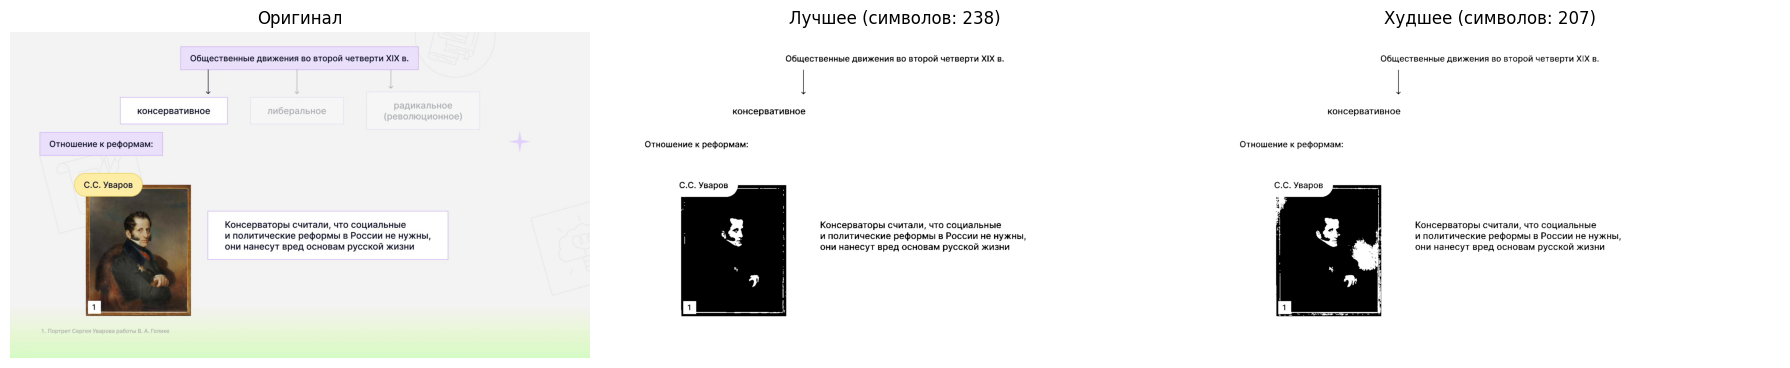

"Лучший текст (символов: 238) α: 0.87, β: 73","Худший текст (символов: 207) α: 1.01, β: 97"
"Общественные движения во второй четверти ХИХ в. | консервативное Отношение к реформам: С.С. Уваров киирииити Е Консерваторы считали, что социальные и политические реформы в России не нужны, они нанесут вред основам русской жизни","Общественные движения во второй четверти ХХ в. | консервативное Отношение к реформам: Консерваторы считали, что социальные и политические реформы в России не нужны, они нанесут вред основам русской жизни"


  0:01:14.547  ₀⡄₁₀⡄₀₃.₀₄₂ keyframe_11.jpg обработан

🔎 Обработка: keyframe_12.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
239 239 239 239 239 239 239 239 239 239 239 239 239 238 238 235 235 235 235 235 235 235 235 235 alpha=0.80
239 239 239 239 239 239 239 239 238 238 235 235 235 235 235 235 235 235 235 235 235 235 235 235 alpha=0.87
239 238 238 238 238 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 alpha=0.94
235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 alpha=1.01
235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 alpha=1.08
235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 alpha=1.15
235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235 235

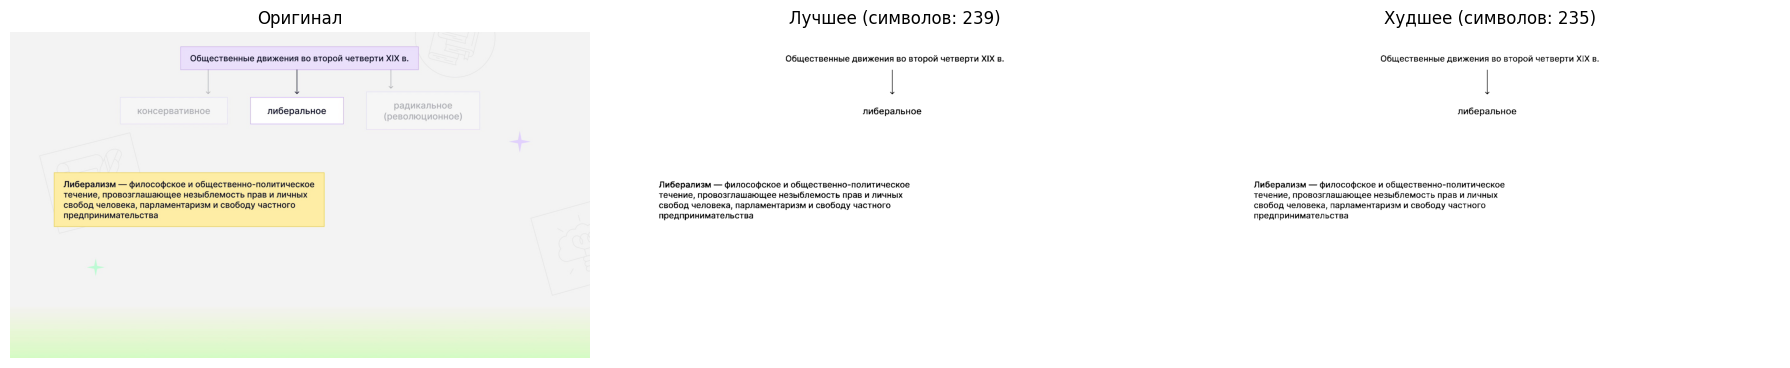

"Лучший текст (символов: 239) α: 0.80, β: 40","Худший текст (символов: 235) α: 0.80, β: 85"
"Общественные движения во второй четверти ХИХ в. | либеральное Либерализм — философское и общественно-политическое течение, провозглашающее незыблемость прав и личных свобод человека, парламентаризм и свободу частного предпринимательства","Общественные движения во второй четверти ХХ в. либеральное Либерализм — философское и общественно-политическое течение, провозглашающее незыблемость прав и личных свобод человека, парламентаризм и свободу частного предпринимательства"


  0:01:14.238  ₀⡄₁₁⡄₁₇.₂₈₁ keyframe_12.jpg обработан

🔎 Обработка: keyframe_14.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
367 367 367 367 367 367 367 367 367 367 367 367 367 367 366 366 366 366 366 366 366 366 366 366 alpha=0.80
367 367 367 367 367 367 367 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 alpha=0.87
367 367 366 367 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 alpha=0.94
366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 alpha=1.01
366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 alpha=1.08
366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 alpha=1.15
366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366 366

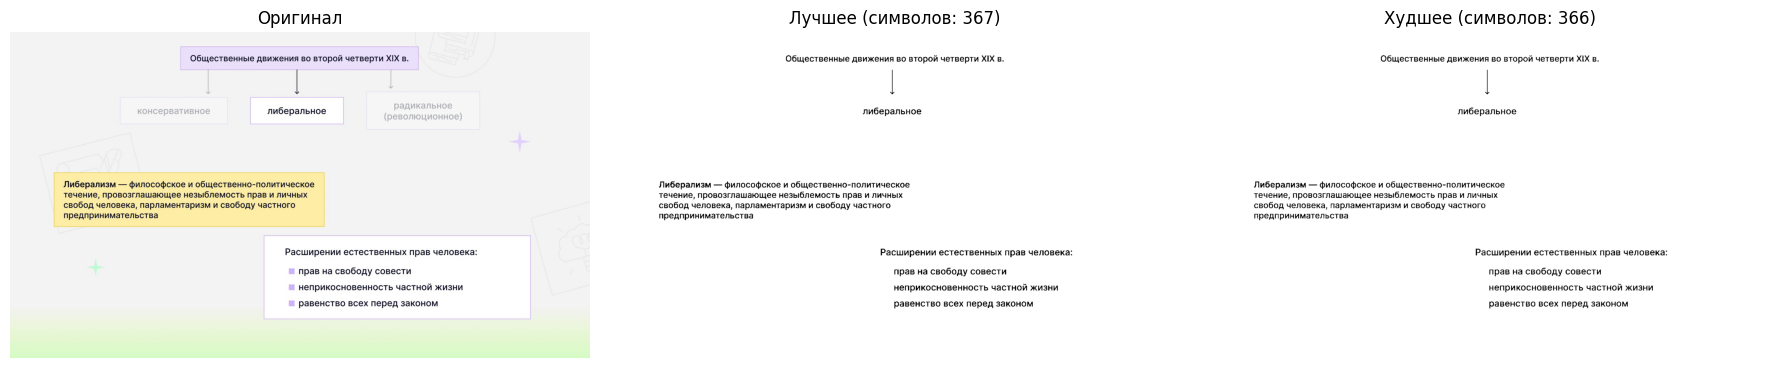

"Лучший текст (символов: 367) α: 0.80, β: 40","Худший текст (символов: 366) α: 0.80, β: 82"
"Общественные движения во второй четверти ХИХ в. | либеральное Либерализм — философское и общественно-политическое течение, провозглашающее незыблемость прав и личных свобод человека, парламентаризм и свободу частного предпринимательства Расширении естественных прав человека: прав на свободу совести неприкосновенность частной жизни равенство всех перед законом","Общественные движения во второй четверти ХХ в. | либеральное Либерализм — философское и общественно-политическое течение, провозглашающее незыблемость прав и личных свобод человека, парламентаризм и свободу частного предпринимательства Расширении естественных прав человека: прав на свободу совести неприкосновенность частной жизни равенство всех перед законом"


  0:01:35.852  ₀⡄₁₂⡄₅₃.₁₃₃ keyframe_14.jpg обработан

🔎 Обработка: keyframe_16.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
199 199 199 199 199 199 199 199 199 199 199 199 198 199 198 198 198 198 198 198 198 198 198 198 alpha=0.80
199 199 199 199 199 199 199 198 199 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 alpha=0.87
198 199 198 199 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 alpha=0.94
198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 alpha=1.01
198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 alpha=1.08
198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 alpha=1.15
198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198

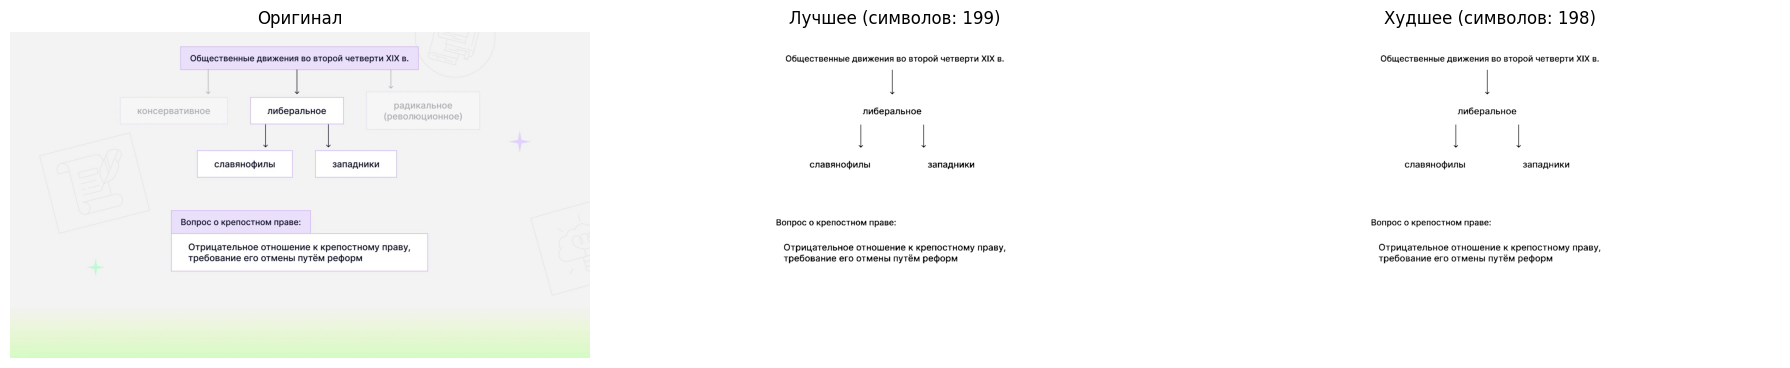

"Лучший текст (символов: 199) α: 0.80, β: 40","Худший текст (символов: 198) α: 0.80, β: 76"
"Общественные движения во второй четверти ХИХ в. | либеральное [| славянофилы западники Вопрос о крепостном праве: Отрицательное отношение к крепостному праву, требование его отмены путём реформ","Общественные движения во второй четверти ХХ в. | либеральное [| славянофилы западники Вопрос о крепостном праве: Отрицательное отношение к крепостному праву, требование его отмены путём реформ"


  0:01:09.550  ₀⡄₁₄⡄₀₂.₆₈₄ keyframe_16.jpg обработан

🔎 Обработка: keyframe_17.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
199 199 199 199 199 199 199 199 199 199 199 199 198 199 198 198 198 198 198 198 198 198 198 198 alpha=0.80
199 199 199 199 199 199 199 198 199 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 alpha=0.87
198 199 198 199 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 alpha=0.94
198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 alpha=1.01
198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 alpha=1.08
198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 alpha=1.15
198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198 198

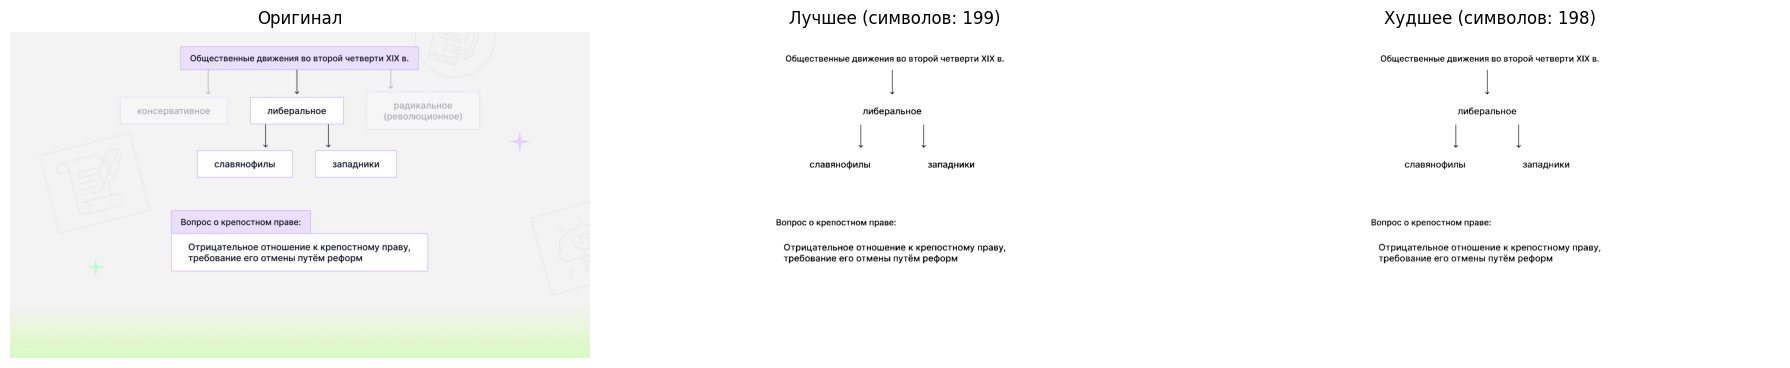

"Лучший текст (символов: 199) α: 0.80, β: 40","Худший текст (символов: 198) α: 0.80, β: 76"
"Общественные движения во второй четверти ХИХ в. | либеральное [| славянофилы западники Вопрос о крепостном праве: Отрицательное отношение к крепостному праву, требование его отмены путём реформ","Общественные движения во второй четверти ХХ в. | либеральное [| славянофилы западники Вопрос о крепостном праве: Отрицательное отношение к крепостному праву, требование его отмены путём реформ"


  0:01:09.051  ₀⡄₁₅⡄₁₁.₇₃₅ keyframe_17.jpg обработан

🔎 Обработка: keyframe_18.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
282 282 282 282 282 282 282 282 282 282 282 282 282 282 281 281 281 278 278 278 278 278 278 278 alpha=0.80
282 282 282 282 282 282 282 282 282 281 281 281 278 278 278 278 278 278 278 278 278 278 278 278 alpha=0.87
282 282 281 282 281 281 281 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 alpha=0.94
281 281 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 alpha=1.01
278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 alpha=1.08
278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 alpha=1.15
278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278 278

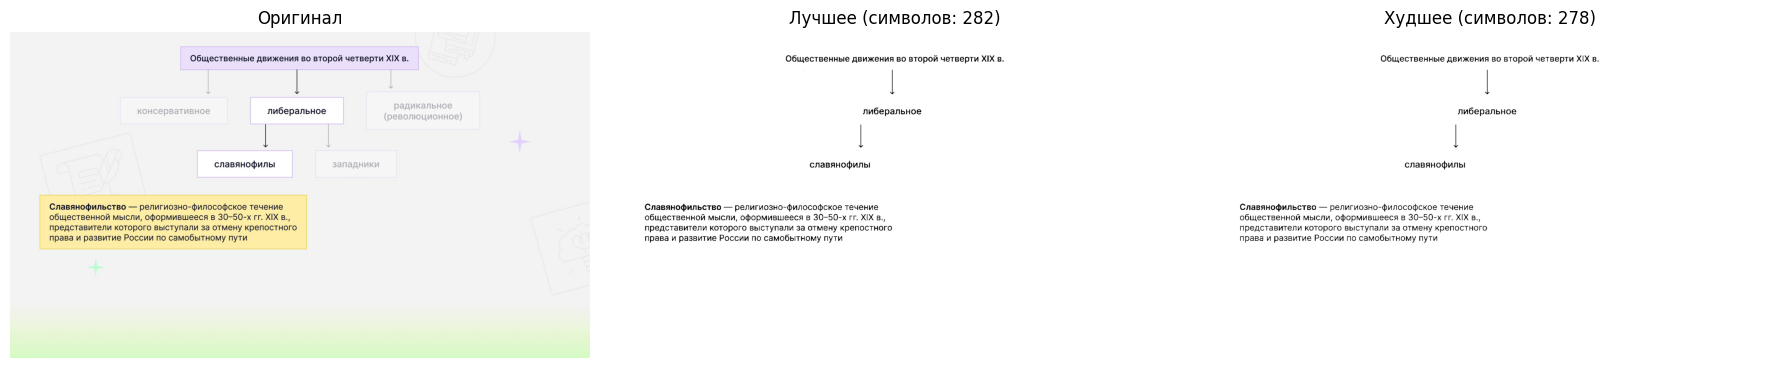

"Лучший текст (символов: 282) α: 0.80, β: 40","Худший текст (символов: 278) α: 0.80, β: 91"
"Общественные движения во второй четверти ХИХ в. | либеральное | славянофилы Славянофильство — религиозно-философское течение общественной мысли, оформившееся в 30-50-х гг. ХХ в., представители которого выступали за отмену крепостного права и развитие России по самобытному пути","Общественные движения во второй четверти ХХ в. либеральное | славянофилы Славянофильство — религиозно-философское течение общественной мысли, оформившееся в 30-50-х гг. ХХ в., представители которого выступали за отмену крепостного права и развитие России по самобытному пути"


  0:01:22.109  ₀⡄₁₆⡄₃₃.₈₄₅ keyframe_18.jpg обработан

🔎 Обработка: keyframe_20.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
356 356 356 356 356 356 356 356 356 356 356 356 356 356 356 355 355 354 354 354 354 354 354 354 alpha=0.80
356 356 356 356 356 356 356 356 355 355 355 355 354 354 354 354 354 354 354 354 354 355 355 355 alpha=0.87
356 356 356 356 356 356 355 354 354 354 354 354 354 354 354 354 355 355 355 355 355 355 355 355 alpha=0.94
355 355 354 354 354 354 354 354 354 354 354 354 355 355 355 355 355 356 355 355 355 355 355 355 alpha=1.01
354 354 354 354 354 354 354 354 355 355 355 355 355 355 355 355 355 355 355 355 355 355 355 355 alpha=1.08
354 354 354 354 355 355 355 355 355 355 355 355 355 355 355 355 355 355 355 355 355 355 355 355 alpha=1.15
355 355 355 355 355 355 355 355 355 355 355 355 355 355 355 355 355 355 355

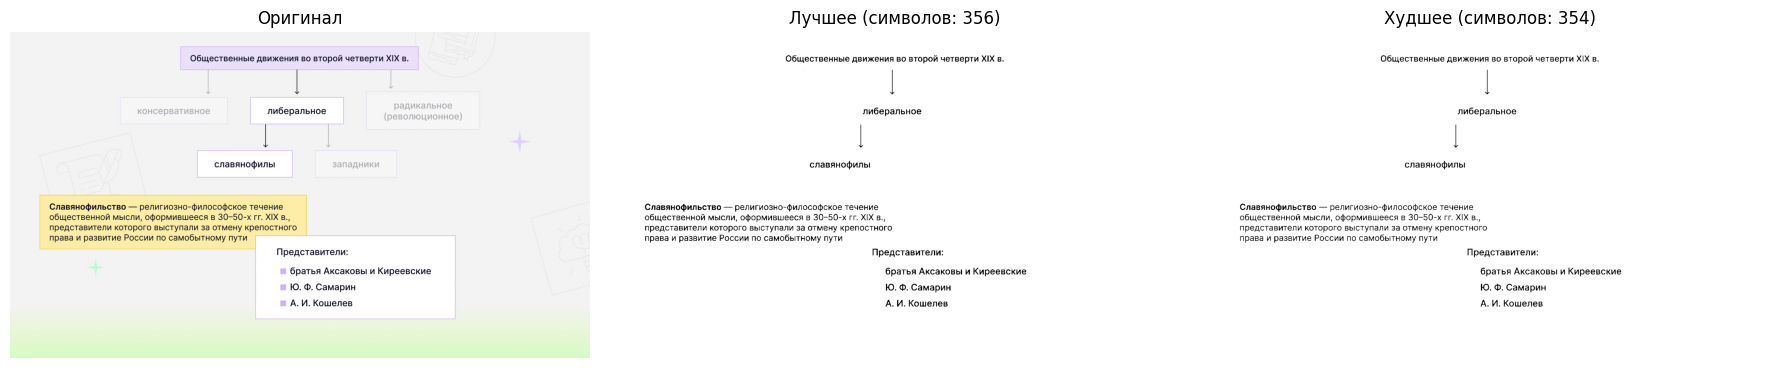

"Лучший текст (символов: 356) α: 0.80, β: 40","Худший текст (символов: 354) α: 0.80, β: 91"
"Общественные движения во второй четверти ХИХ в. | либеральное | славянофилы Славянофильство — религиозно-философское течение общественной мысли, оформившееся в 30-50-х гг. ХХ в., представители которого выступали за отмену крепостного права и развитие России по самобытному пути Представители: братья Аксаковы и Киреевские Ю. Ф. Самарин А. И. Кошелев","Общественные движения во второй четверти ХХ в. | либеральное | славянофилы Славянофильство — религиозно-философское течение общественной мысли, оформившееся в 30-50-х гг. ХХ в., представители которого выступали за отмену крепостного права и развитие России по самобытному пути Представители: братья Аксаковы и Киреевские Ю. Ф. Самарин А. И. Кошелев"


  0:01:33.209  ₀⡄₁₈⡄₀₇.₀₅₅ keyframe_20.jpg обработан

🔎 Обработка: keyframe_21.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
302 302 302 302 302 302 302 302 304 305 305 305 305 303 305 306 302 302 304 304 304 304 304 310 alpha=0.80
302 302 302 304 305 305 305 302 303 305 305 302 302 302 304 304 304 304 310 310 305 301 301 301 alpha=0.87
305 305 303 303 305 306 302 302 302 304 304 304 304 304 310 305 305 301 301 298 302 305 305 305 alpha=0.94
305 302 302 302 304 304 304 304 304 304 310 305 305 301 301 301 305 303 305 305 304 304 304 304 alpha=1.01
304 304 304 304 304 310 311 305 304 301 298 301 302 303 305 305 316 304 304 307 307 307 304 322 alpha=1.08
304 311 310 305 304 301 301 301 302 302 305 305 305 304 304 304 304 304 304 318 307 307 309 306 alpha=1.15
304 301 301 301 302 302 305 305 305 319 304 304 304 307 307 304 301 307 307

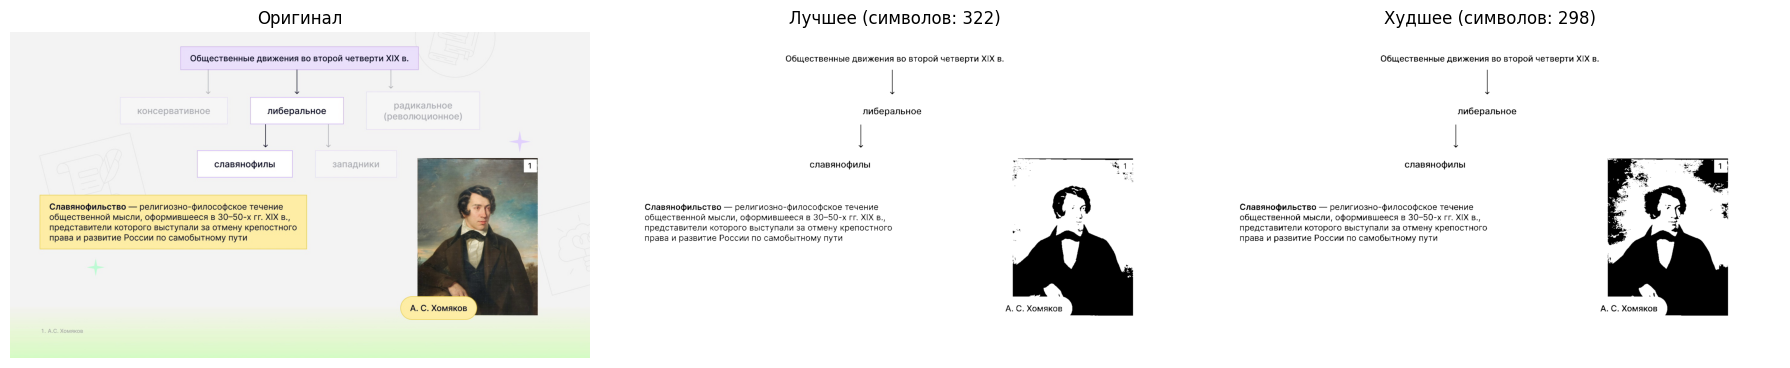

"Лучший текст (символов: 322) α: 1.08, β: 109","Худший текст (символов: 298) α: 0.94, β: 97"
"Общественные движения во второй четверти ХХ в. | либеральное | славянофилы „# ча > | Славянофильство — религиозно-философское течение общественной мысли, оформившееся в 30-50-х гг. ХХ в., представители которого выступали за отмену крепостного права и развитие России по самобытному пути ` А. С. Хомяков","Общественные движения во второй четверти ХХ в. либеральное | славянофилы Славянофильство — религиозно-философское течение общественной мысли, оформившееся в 30-50-х гг. ХХ в., представители которого выступали за отмену крепостного права и развитие России по самобытному пути А. С. Хомяков"


  0:01:27.937  ₀⡄₁₉⡄₃₄.₉₉₃ keyframe_21.jpg обработан

🔎 Обработка: keyframe_22.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
431 431 431 431 431 431 431 431 434 434 434 434 431 431 435 431 431 431 431 431 431 431 434 434 alpha=0.80
431 431 434 434 434 434 434 431 434 434 431 431 431 431 431 431 431 433 435 433 430 430 434 434 alpha=0.87
434 431 431 431 435 431 431 431 431 431 431 431 430 434 434 434 430 430 430 434 434 434 443 432 alpha=0.94
431 431 431 431 431 431 431 431 434 433 434 433 430 430 434 434 434 434 443 432 432 432 432 432 alpha=1.01
431 431 431 431 435 434 434 433 430 430 434 434 434 434 434 432 432 432 435 432 432 439 440 439 alpha=1.08
434 434 434 430 430 430 430 434 434 434 434 432 432 432 432 432 432 432 437 440 438 444 439 443 alpha=1.15
430 430 430 434 434 434 434 445 432 432 432 432 432 432 437 440 437 438 444

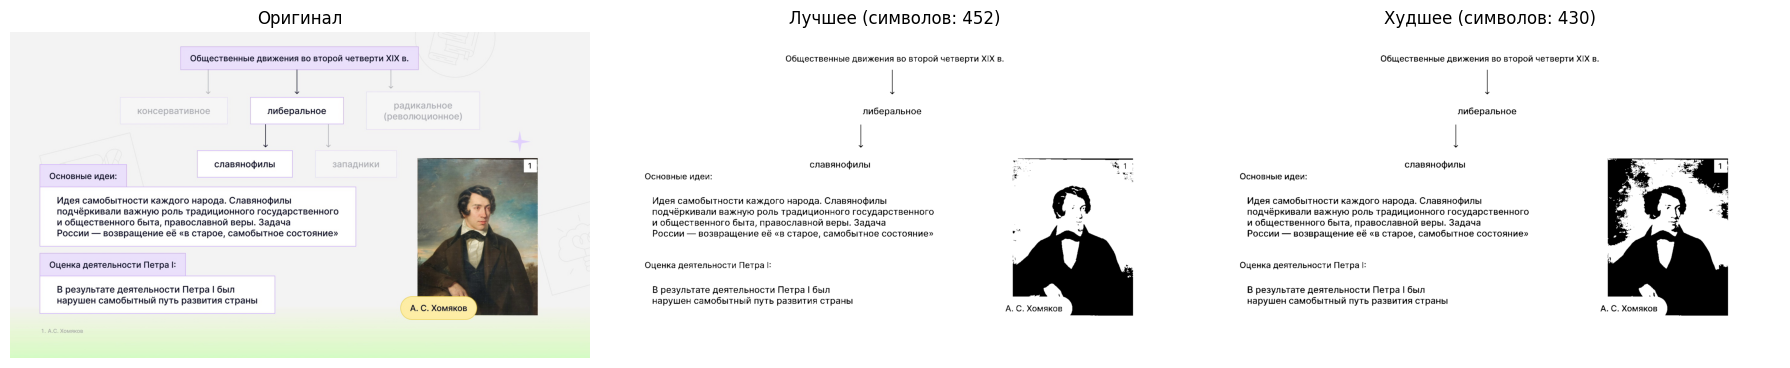

"Лучший текст (символов: 452) α: 1.36, β: 64","Худший текст (символов: 430) α: 0.87, β: 100"
"Общественные движения во второй четверти ХХ в. | либеральное | славянофилы ‚й ча > р Основные идеи: Идея самобытности каждого народа. Славянофилы подчёркивали важную роль традиционного государственного и общественного быта, православной веры. Задача России — возвращение её «в старое, самобытное состояние» Оценка деятельности Петра |: В результате деятельности Петра | был нарушен самобытный путь развития страны ` А. С. Хомяков","Общественные движения во второй четверти ХХ в. | либеральное | славянофилы Основные идеи: Идея самобытности каждого народа. Славянофилы подчёркивали важную роль традиционного государственного и общественного быта, православной веры. Задача России — возвращение её «в старое, самобытное состояние» Оценка деятельности Петра |: В результате деятельности Петра | был нарушен самобытный путь развития страны А. С. Хомяков"


  0:01:49.107  ₀⡄₂₁⡄₂₄.₁₀₁ keyframe_22.jpg обработан

🔎 Обработка: keyframe_23.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
318 318 318 318 318 318 318 318 318 321 321 321 318 318 318 318 318 318 318 318 318 318 321 321 alpha=0.80
318 318 318 321 321 321 321 318 318 318 318 318 318 318 318 318 318 318 321 321 320 317 317 321 alpha=0.87
321 321 318 318 318 318 318 318 318 318 318 318 318 318 321 321 320 317 317 321 320 321 321 332 alpha=0.94
318 318 318 318 318 318 318 318 318 321 321 321 320 317 317 321 321 321 321 332 320 320 320 320 alpha=1.01
318 318 318 318 318 322 321 321 317 317 317 321 321 321 321 321 320 320 320 323 323 320 326 323 alpha=1.08
317 321 321 321 317 317 317 321 321 321 321 321 320 320 320 320 320 323 320 324 323 327 329 331 alpha=1.15
317 317 317 317 321 321 321 321 333 320 320 320 323 320 320 326 327 323 324

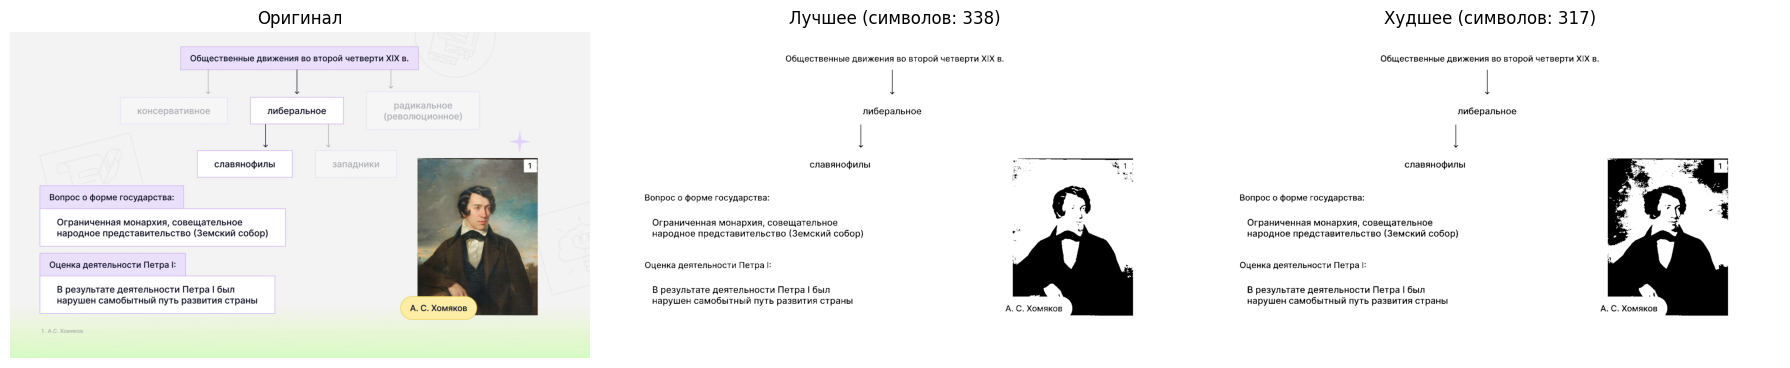

"Лучший текст (символов: 338) α: 1.36, β: 67","Худший текст (символов: 317) α: 0.87, β: 103"
"Общественные движения во второй четверти ХХ в. | либеральное | славянофилы ‚й ча > р Вопрос о форме государства: Ограниченная монархия, совещательное народное представительство (Земский собор} Оценка деятельности Петра |: В результате деятельности Петра | был нарушен самобытный путь развития страны ` А. С. Хомяков","Общественные движения во второй четверти ХХ в. | либеральное | славянофилы Вопрос о форме государства: Ограниченная монархия, совещательное народное представительство (Земский собор} Оценка деятельности Петра |: В результате деятельности Петра | был нарушен самобытный путь развития страны А. С. Хомяков"


  0:01:30.134  ₀⡄₂₂⡄₅₄.₂₃₆ keyframe_23.jpg обработан

🔎 Обработка: keyframe_24.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
318 318 318 318 318 318 318 318 318 321 321 321 318 318 318 318 318 318 318 318 318 318 321 321 alpha=0.80
318 318 318 321 321 321 321 318 318 318 318 318 318 318 318 318 318 318 321 321 320 317 317 321 alpha=0.87
321 321 318 318 318 318 318 318 318 318 318 318 318 318 321 321 320 317 317 321 320 321 321 332 alpha=0.94
318 318 318 318 318 318 318 318 318 321 321 321 320 317 317 321 321 321 321 332 320 320 320 320 alpha=1.01
318 318 318 318 318 322 321 321 317 317 317 321 321 321 321 321 320 320 320 323 323 320 326 323 alpha=1.08
317 321 321 321 317 317 317 321 321 321 321 321 320 320 320 320 320 323 320 324 323 327 329 331 alpha=1.15
317 317 317 317 321 321 321 321 333 320 320 320 323 320 320 326 327 323 324

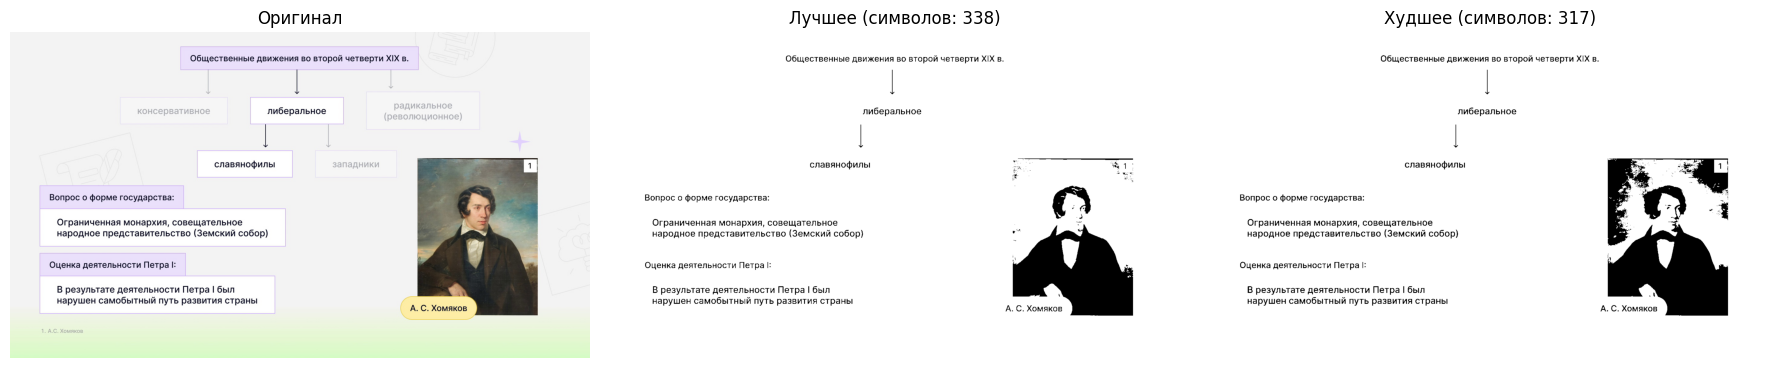

"Лучший текст (символов: 338) α: 1.36, β: 67","Худший текст (символов: 317) α: 0.87, β: 103"
"Общественные движения во второй четверти ХХ в. | либеральное | славянофилы ‚й ча > р Вопрос о форме государства: Ограниченная монархия, совещательное народное представительство (Земский собор} Оценка деятельности Петра |: В результате деятельности Петра | был нарушен самобытный путь развития страны ` А. С. Хомяков","Общественные движения во второй четверти ХХ в. | либеральное | славянофилы Вопрос о форме государства: Ограниченная монархия, совещательное народное представительство (Земский собор} Оценка деятельности Петра |: В результате деятельности Петра | был нарушен самобытный путь развития страны А. С. Хомяков"


  0:01:30.601  ₀⡄₂₄⡄₂₄.₈₃₇ keyframe_24.jpg обработан

🔎 Обработка: keyframe_25.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
430 430 430 430 430 430 430 430 430 430 430 430 430 430 430 429 429 429 429 429 429 429 429 429 alpha=0.80
430 430 430 430 430 430 430 430 429 429 429 429 429 429 429 429 429 429 429 429 429 429 429 429 alpha=0.87
430 430 430 430 429 429 429 429 429 429 429 429 429 429 429 429 429 429 429 429 429 429 428 428 alpha=0.94
429 429 429 429 429 429 429 429 429 429 429 429 429 429 429 429 429 429 428 428 428 428 428 428 alpha=1.01
429 429 429 429 429 429 429 429 429 429 429 429 429 429 429 428 428 428 428 428 428 428 428 428 alpha=1.08
429 429 429 429 429 429 429 429 429 429 428 428 428 428 428 428 428 428 428 428 428 428 428 428 alpha=1.15
429 429 429 429 429 429 429 428 428 428 428 428 428 428 428 428 428 428 428

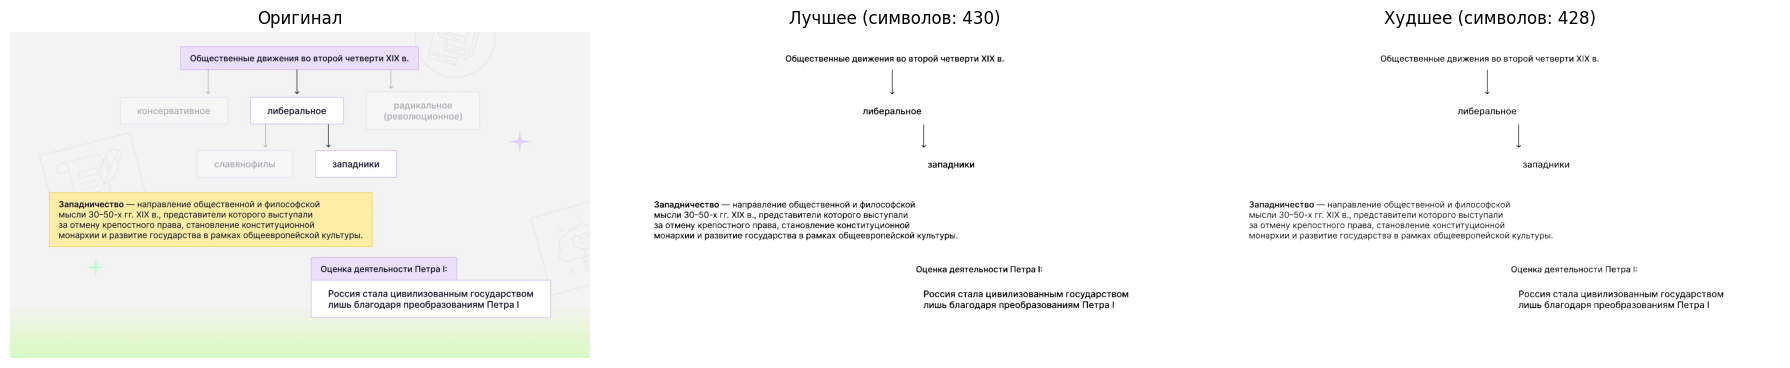

"Лучший текст (символов: 430) α: 0.80, β: 40","Худший текст (символов: 428) α: 0.94, β: 106"
"Общественные движения во второй четверти ХИХ в. | либеральное | западники Западничество — направление общественной и философской мысли 30-50-х гг. ХИХ в., представители которого выступали за отмену крепостного права, становление конституционной монархии и развитие государства в рамках общеевропейской культуры. Оценка деятельности Петра 1; Россия стала цивилизованным государством лишь благодаря преобразованиям Петра |","Общественные движения во второй четверти ХХ в. | либеральное | западники Западничество — направление общественной и философской мысли 30-50-х гг. ЖХ в., представители которого выступали за отмену крепостного права, становление конституционной монархии и развитие государства в рамках общеевропейской культуры. Оценка деятельности Петра |: Россия стала цивилизованным государством лишь благодаря преобразованиям Петра |"


  0:01:45.484  ₀⡄₂₆⡄₁₀.₃₂₁ keyframe_25.jpg обработан

🔎 Обработка: keyframe_27.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
372 372 372 372 372 372 372 372 372 372 372 372 371 372 371 371 371 371 371 371 371 371 371 371 alpha=0.80
372 372 372 372 372 372 372 371 372 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 alpha=0.87
371 372 371 372 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 alpha=0.94
371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 alpha=1.01
371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 alpha=1.08
371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 alpha=1.15
371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371 371

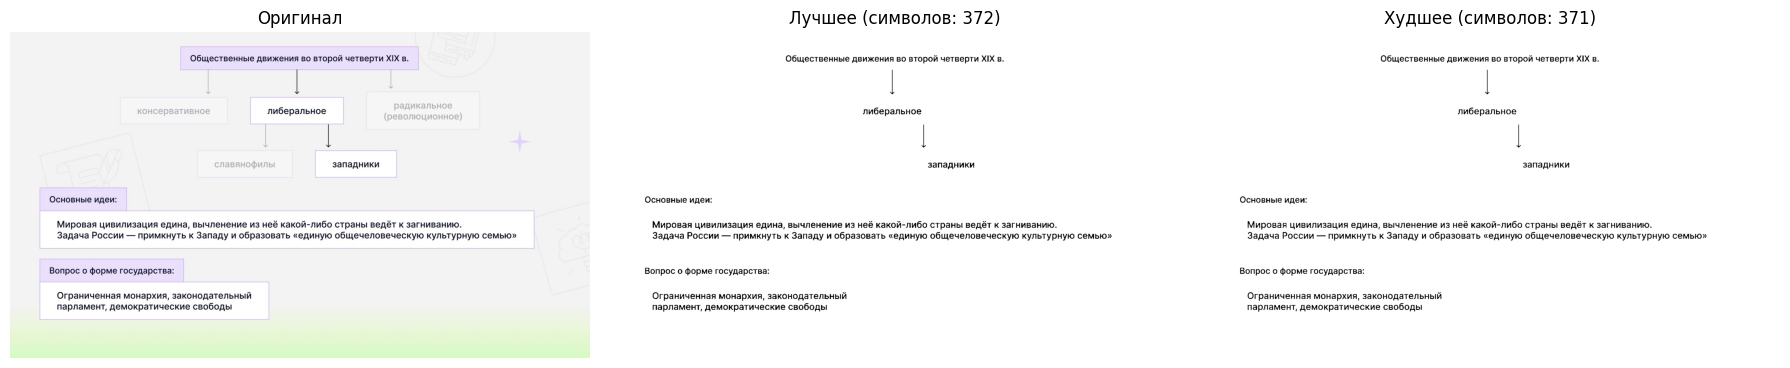

"Лучший текст (символов: 372) α: 0.80, β: 40","Худший текст (символов: 371) α: 0.80, β: 76"
"Общественные движения во второй четверти ХИХ в. | либеральное | западники Основные идеи: Мировая цивилизация едина, вычленение из неё какой-либо страны ведёт к загниванию. Задача России — примкнуть к Западу и образовать «единую общечеловеческую культурную семью» Вопрос о форме государства: Ограниченная монархия, законодательный парламент, демократические свободы","Общественные движения во второй четверти ХХ в. | либеральное | западники Основные идеи: Мировая цивилизация едина, вычленение из неё какой-либо страны ведёт к загниванию. Задача России — примкнуть к Западу и образовать «единую общечеловеческую культурную семью» Вопрос о форме государства: Ограниченная монархия, законодательный парламент, демократические свободы"


  0:01:39.114  ₀⡄₂₇⡄₄₉.₄₃₆ keyframe_27.jpg обработан

🔎 Обработка: keyframe_29.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
185 185 185 185 185 185 185 185 185 185 185 185 185 185 185 184 184 184 184 184 184 184 184 184 alpha=0.80
185 185 185 185 185 185 185 185 185 185 184 184 184 184 184 184 184 184 184 184 184 184 184 184 alpha=0.87
185 185 184 185 185 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 alpha=0.94
184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 alpha=1.01
184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 alpha=1.08
184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 alpha=1.15
184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184 184

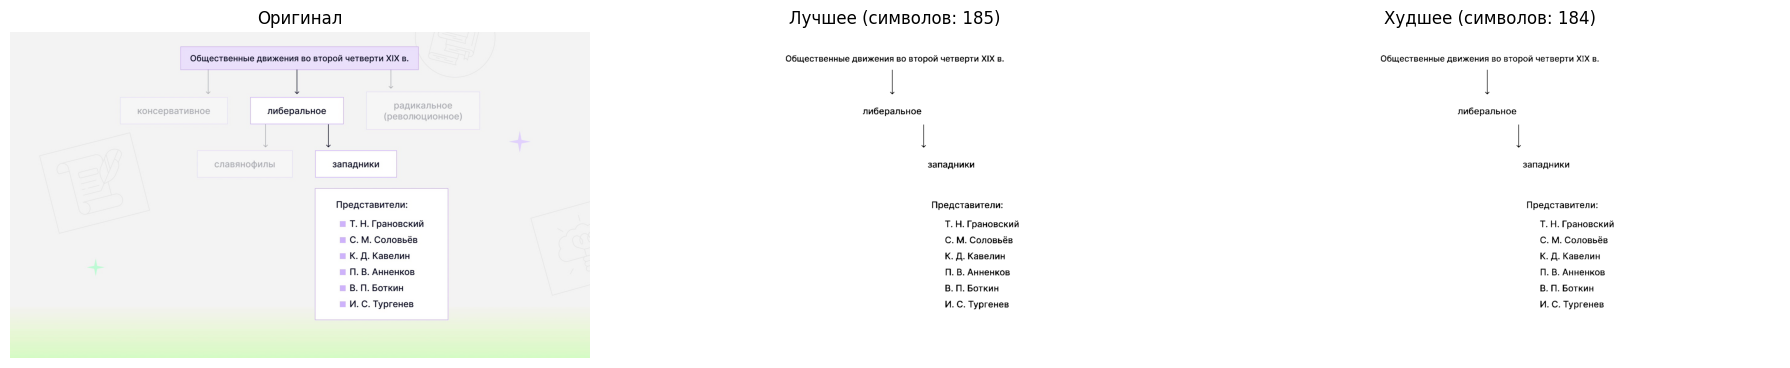

"Лучший текст (символов: 185) α: 0.80, β: 40","Худший текст (символов: 184) α: 0.80, β: 85"
Общественные движения во второй четверти ХИХ в. | либеральное | западники Представители: Т. Н. Грановский С. М. Соловьёв К. Д. Кавелин П. В. Анненков В. П. Боткин И. С. Тургенев,Общественные движения во второй четверти ХХ в. | либеральное | западники Представители: Т. Н. Грановский С. М. Соловьёв К. Д. Кавелин П. В. Анненков В. П. Боткин И. С. Тургенев


  0:01:04.349  ₀⡄₂₈⡄₅₃.₇₈₅ keyframe_29.jpg обработан

🔎 Обработка: keyframe_30.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
197 197 197 197 197 197 197 197 197 197 197 197 197 197 196 196 196 196 196 196 196 196 196 196 alpha=0.80
197 197 197 197 197 197 197 196 197 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 alpha=0.87
196 197 196 197 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 alpha=0.94
196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 alpha=1.01
196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 alpha=1.08
196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 202 213 alpha=1.15
196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196 196

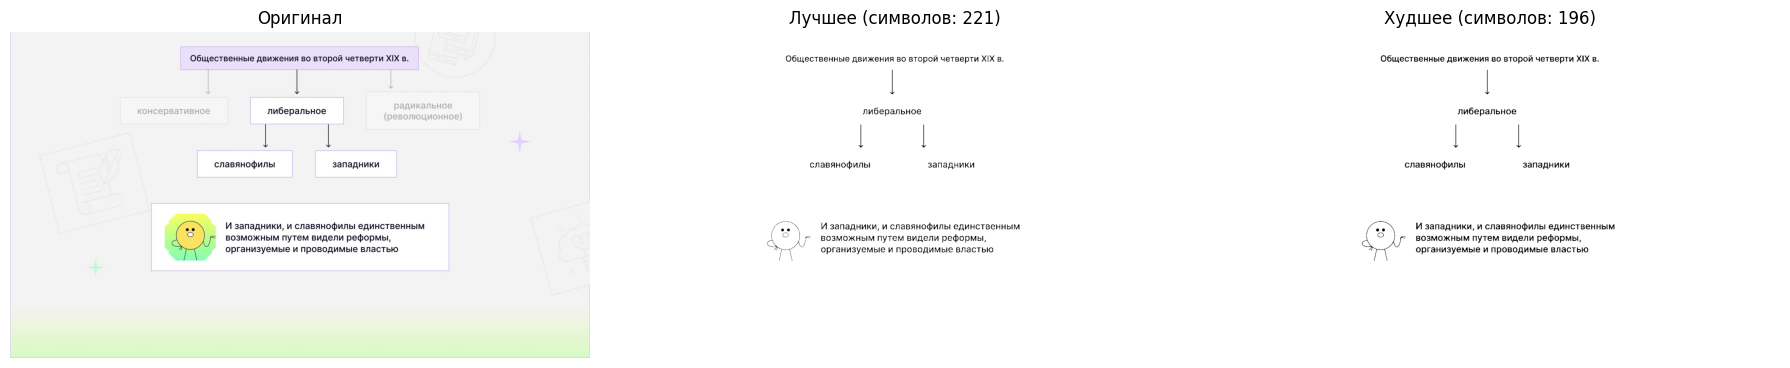

"Лучший текст (символов: 221) α: 1.29, β: 106","Худший текст (символов: 196) α: 0.80, β: 82"
"Общественные движения во второй четверти ХХ в. | либеральное [| славянофилы западники и... И западники, и славянофилы единственным х” | = возможным путем видели реформы, > —^ организуемые и проводимые властью { \ \","Общественные движения во второй четверти ХХ в. | либеральное [| славянофилы западники И западники, и славянофилы единственным возможным путем видели реформы, организуемые и проводимые властью"


  0:01:09.370  ₀⡄₃₀⡄₀₃.₁₅₆ keyframe_30.jpg обработан

🔎 Обработка: keyframe_32.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
271 271 271 271 271 271 271 271 271 271 271 271 271 271 271 271 271 271 270 270 270 270 270 270 alpha=0.80
271 271 271 271 271 271 271 271 271 271 271 271 270 271 270 270 270 271 270 270 270 270 270 270 alpha=0.87
271 271 271 271 271 271 271 270 270 270 270 270 270 271 270 270 270 270 270 270 271 270 270 270 alpha=0.94
271 271 270 270 270 270 270 270 270 270 270 270 270 270 270 270 271 270 270 270 270 270 270 270 alpha=1.01
270 270 270 270 271 270 270 270 270 270 270 270 271 270 270 270 270 270 270 270 270 270 270 270 alpha=1.08
271 270 270 270 270 270 270 270 270 270 270 270 270 270 270 270 270 270 270 270 270 270 270 270 alpha=1.15
270 270 270 270 270 270 270 270 270 270 270 270 270 270 270 270 270 270 270

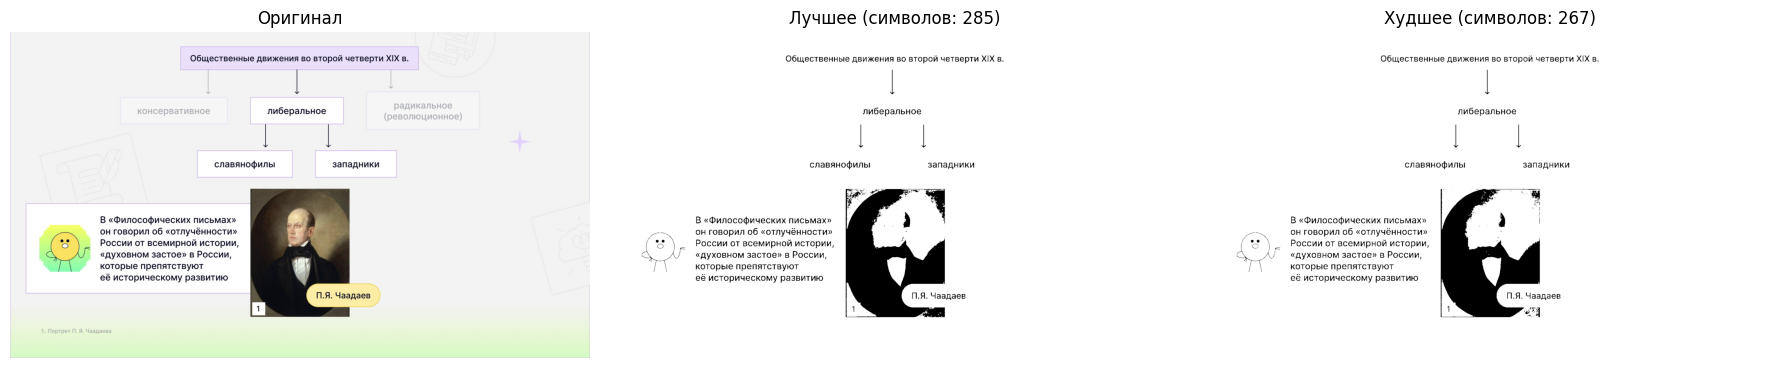

"Лучший текст (символов: 285) α: 1.36, β: 103","Худший текст (символов: 267) α: 1.50, β: 100"
"№ 0, _/ л И Общественные движения во второй четверти ХХ в. | либеральное [| славянофилы западники В «Философических письмах» он говорил об «отлучённости» России от всемирной истории, «духовном застое» в России, которые препятствуют её историческому развитию П.Я. Чаадаев","Общественные движения во второй четверти ХХ в. | либеральное [| славянофилы западники В «Философических письмах» он говорил об «отлучённости» России от всемирной истории, «духовном застое» в России, которые препятствуют её историческому развитию . Чаадаев"


  0:01:21.469  ₀⡄₃₁⡄₂₄.₆₂₆ keyframe_32.jpg обработан

🔎 Обработка: keyframe_33.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
192 192 192 192 192 192 192 192 192 192 192 192 192 192 192 192 192 191 192 191 191 191 191 191 alpha=0.80
192 192 192 192 192 192 192 192 192 192 192 192 191 191 191 191 191 191 191 191 191 191 191 191 alpha=0.87
192 192 192 192 192 192 191 192 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 alpha=0.94
192 192 192 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 alpha=1.01
191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 alpha=1.08
191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 alpha=1.15
191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191 191

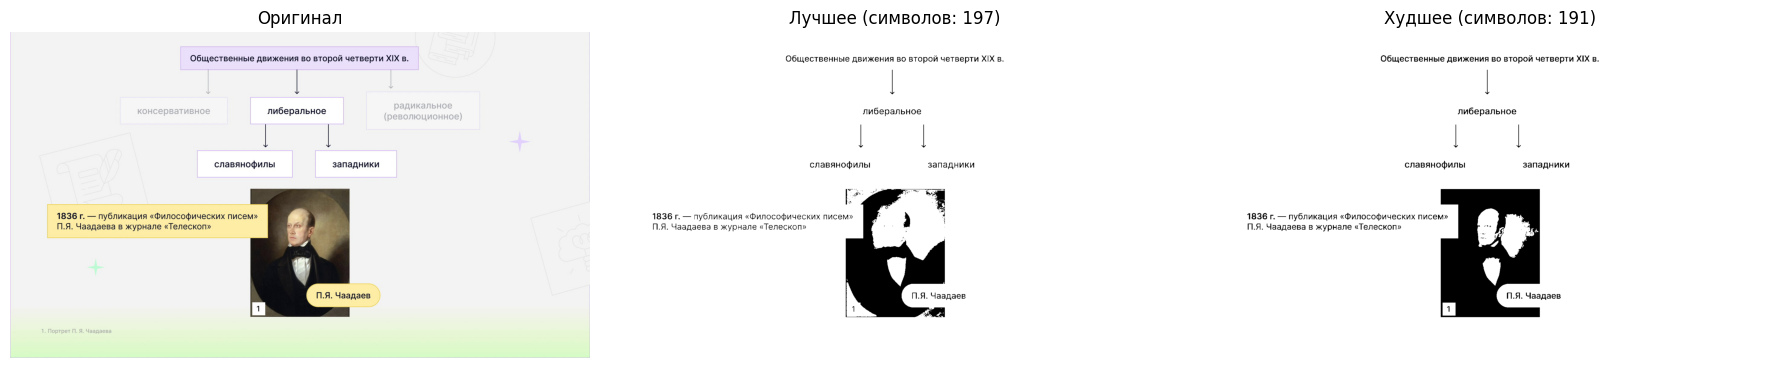

"Лучший текст (символов: 197) α: 1.57, β: 88","Худший текст (символов: 191) α: 0.80, β: 91"
Общественные движения во второй четверти ХХ в. | либеральное [| славянофилы западники 2: ; 1836 г. — публикация «Философических писем» П.Я. Чаадаева в журнале «Телескоп» П.Я. Чаадаев,Общественные движения во второй четверти ХХ в. | либеральное [| славянофилы западники 1836 г. — публикация «Философических писем» П.Я. Чаадаева в журнале «Телескоп» П.Я. Чаадаев


  0:01:07.820  ₀⡄₃₂⡄₃₂.₄₄₆ keyframe_33.jpg обработан

🔎 Обработка: keyframe_38.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
252 252 252 252 252 252 252 252 252 252 252 252 252 251 252 251 251 251 251 251 251 251 251 251 alpha=0.80
252 252 252 252 252 252 252 252 251 252 251 251 251 251 251 251 251 251 251 251 251 251 251 251 alpha=0.87
252 251 252 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 alpha=0.94
251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 alpha=1.01
251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 254 alpha=1.08
251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 254 251 258 257 261 alpha=1.15
251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 251 254 258 257

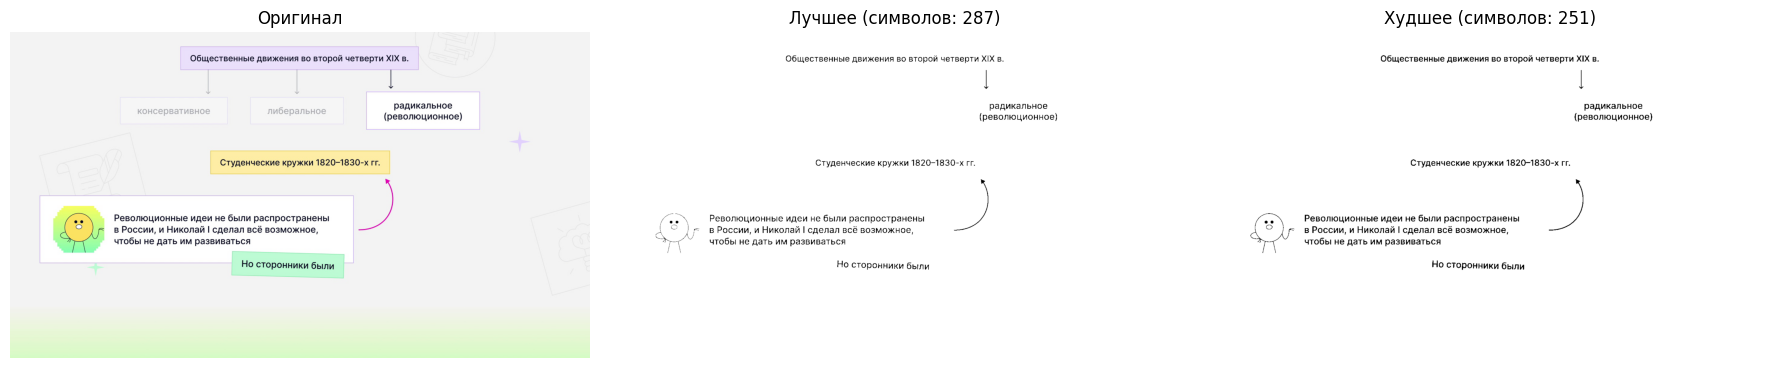

"Лучший текст (символов: 287) α: 1.57, β: 88","Худший текст (символов: 251) α: 0.80, β: 79"
"Общественные движения во второй четверти ХХХ в. | радикальное (революционное) Студенческие кружки 1820-1830-х гг. с и. .^ Революционные идеи не были распространены : ‚= в России, и Николай | сделал всё возможное, | | ^^ | \/ <. чтобы не дать им развиваться Но сторонники были","Общественные движения во второй четверти ХХ в. | радикальное {революционное} Студенческие кружки 1820-1830-х гг. Революционные идеи не были распространены в России, и Николай | сделал всё возможное, чтобы не дать им развиваться Но сторонники были"


  0:01:15.552  ₀⡄₃₃⡄₄₇.₉₉₈ keyframe_38.jpg обработан

🔎 Обработка: keyframe_40.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
239 239 239 239 239 239 239 239 239 239 239 239 239 238 239 239 238 238 238 238 238 238 238 238 alpha=0.80
239 239 239 239 239 239 239 239 238 239 238 238 238 238 238 238 238 238 238 238 238 238 238 238 alpha=0.87
239 239 238 238 239 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 alpha=0.94
239 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 alpha=1.01
238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 alpha=1.08
238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 alpha=1.15
238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238 238

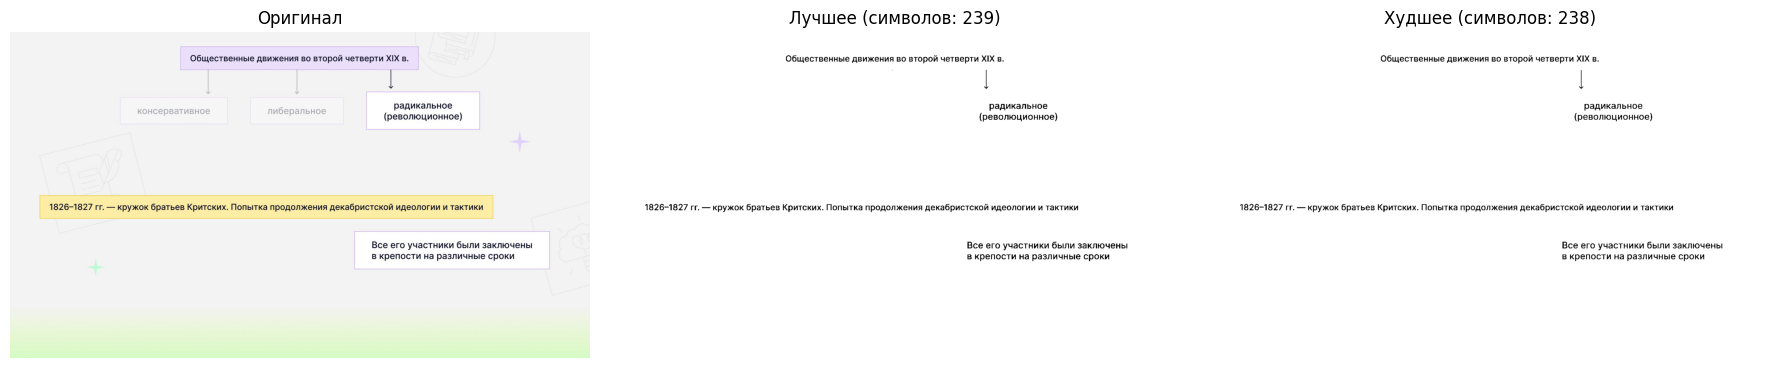

"Лучший текст (символов: 239) α: 0.80, β: 40","Худший текст (символов: 238) α: 0.80, β: 79"
Общественные движения во второй четверти ХИХ в. | радикальное (революционное) 1826-1827 гг. — кружок братьев Критских. Попытка продолжения декабристской идеологии и тактики Все его участники были заключены в крепости на различные сроки,Общественные движения во второй четверти ХХ в. | радикальное {революционное} 1826-1827 гг. — кружок братьев Критских. Попытка продолжения декабристской идеологии и тактики Все его участники были заключены в крепости на различные сроки


  0:01:13.090  ₀⡄₃₅⡄₀₁.₀₈₈ keyframe_40.jpg обработан

🔎 Обработка: keyframe_43.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
425 425 425 425 418 418 418 418 418 418 418 425 425 425 425 425 425 425 425 425 425 425 425 425 alpha=0.80
418 418 418 418 418 418 423 423 425 425 425 425 425 425 425 425 425 425 425 424 425 424 424 424 alpha=0.87
423 425 423 425 425 425 425 425 425 425 425 425 425 425 425 424 425 425 424 424 424 424 428 424 alpha=0.94
425 425 425 425 425 425 425 425 425 425 425 424 425 425 424 424 424 427 431 429 424 424 435 437 alpha=1.01
425 425 425 425 425 425 425 425 425 425 424 424 424 427 431 428 424 424 424 424 438 438 431 433 alpha=1.08
425 425 424 424 425 424 424 424 424 427 424 428 424 424 424 438 435 438 435 430 434 427 429 431 alpha=1.15
425 424 424 424 424 427 424 430 429 424 424 424 435 437 438 435 431 436 433

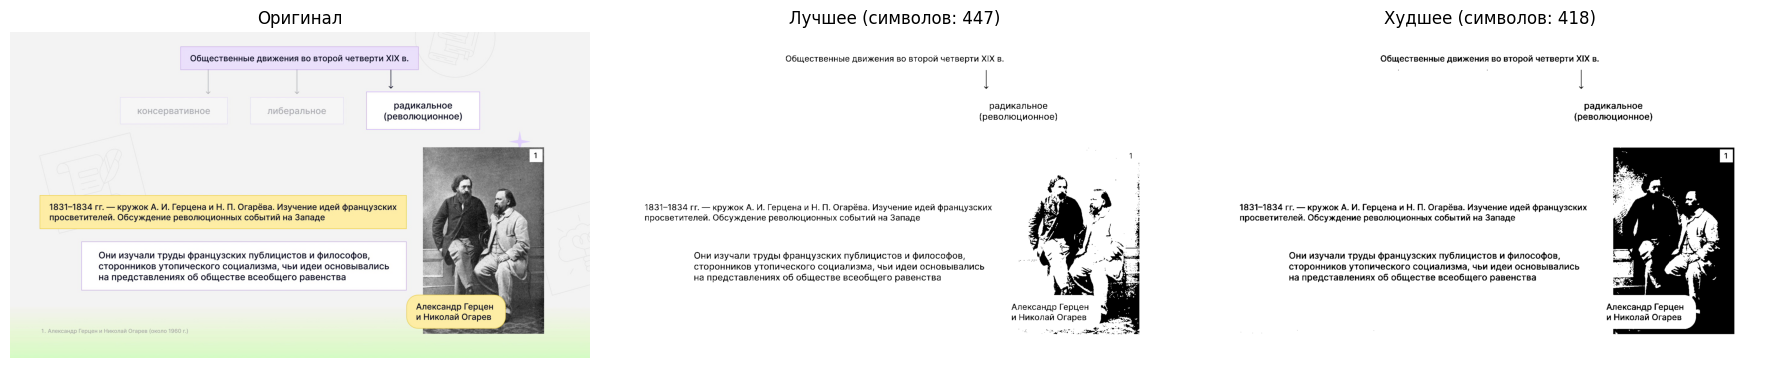

"Лучший текст (символов: 447) α: 1.43, β: 94","Худший текст (символов: 418) α: 0.80, β: 52"
"Общественные движения во второй четверти ХХ в. | радикальное (революционное) 1831-1834 гг. — кружок А. И. Герцена и Н. П. Огарёва. Изучение идей французских просветителей. Обсуждение революционных событий на Западе Они изучали труды французских публицистов и философов, сторонников утопического социализма, чьи идеи основывались на представлениях об обществе всеобщего равенства Александр Герцен . и Николай Огарев р >. Е. Зач еще торе","Общественные движения во второй четверти ХИХ в. | радикальное (революционное) 1831-1834 гг. — кружок А. И. Герцена и Н. П. Огарёва. Изучение идей французских просветителей. Обсуждение революционных событий на Западе Они изучали труды французских публицистов и философов, сторонников утопического социализма, чьи идеи основывались на представлениях об обществе всеобщего равенства Александр Герцен и Николай Огарев"


  0:01:46.019  ₀⡄₃₆⡄₄₇.₁₀₈ keyframe_43.jpg обработан

🔎 Обработка: keyframe_44.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
244 244 244 244 244 244 244 244 218 218 218 218 218 218 218 218 218 218 218 218 218 218 218 218 alpha=0.80
245 245 241 218 218 218 218 218 218 218 218 218 218 218 218 218 218 218 217 218 217 220 217 233 alpha=0.87
218 218 218 218 218 218 218 218 218 218 218 218 218 218 217 218 223 220 217 217 217 220 217 217 alpha=0.94
218 218 218 218 218 218 218 218 218 218 217 218 223 220 217 217 217 217 217 230 217 265 272 240 alpha=1.01
218 218 218 218 218 217 217 218 217 220 217 217 217 217 240 220 257 287 287 253 246 240 246 259 alpha=1.08
218 218 218 221 217 217 217 217 217 217 217 231 225 217 270 256 250 246 240 248 260 267 267 233 alpha=1.15
217 217 217 217 217 217 217 217 227 243 281 261 233 251 255 238 252 254 254

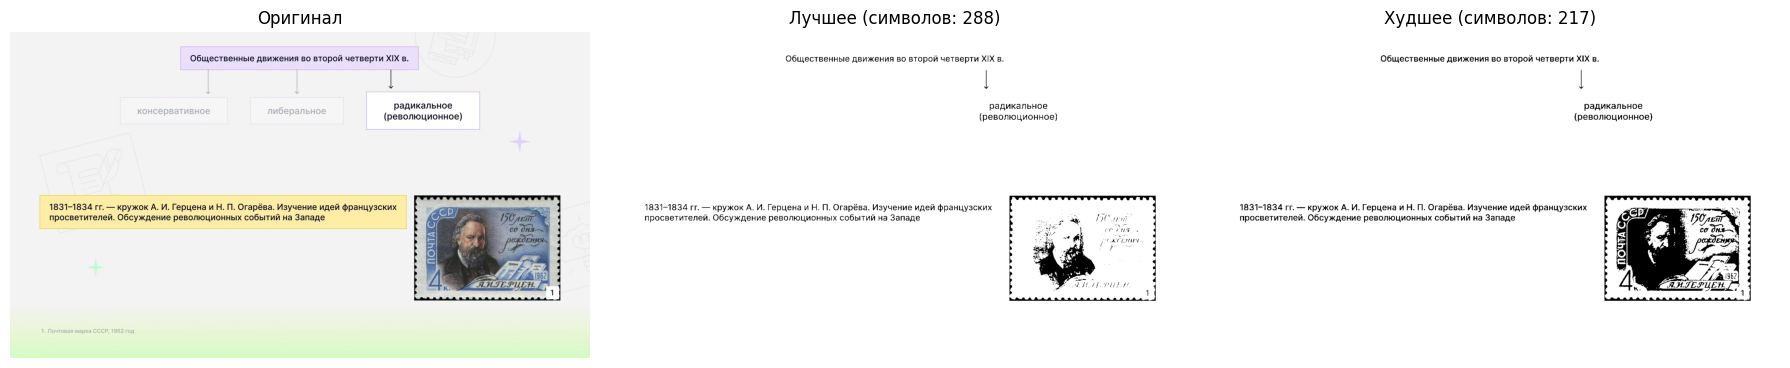

"Лучший текст (символов: 288) α: 1.43, β: 103","Худший текст (символов: 217) α: 0.87, β: 94"
Общественные движения во второй четверти ХХ в. | радикальное (революционное) 1831-1834 гг. — кружок А. И. Герцена и Н. П. Огарёва. Изучение идей французских просветителей. Обсуждение революционных событий на Западе 2 3% Слет : х- ге Гия х жесптич ие ее зла АИ И,Общественные движения во второй четверти ХХ в. | радикальное {революционное} 1831-1834 гг. — кружок А. И. Герцена и Н. П. Огарёва. Изучение идей французских просветителей. Обсуждение революционных событий на Западе


  0:01:18.341  ₀⡄₃₈⡄₀₅.₄₄₉ keyframe_44.jpg обработан

🔎 Обработка: keyframe_45.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
384 384 384 384 384 384 351 351 319 309 309 309 288 288 309 309 288 288 309 313 309 288 309 288 alpha=0.80
371 371 297 309 309 309 288 288 309 311 288 290 288 309 313 309 288 309 309 288 292 308 288 308 alpha=0.87
309 288 288 309 309 311 290 288 309 309 288 309 288 309 288 288 309 308 288 289 287 287 287 287 alpha=0.94
311 290 288 288 288 313 309 288 288 309 288 288 313 308 288 309 308 287 287 287 287 287 287 287 alpha=1.01
309 309 288 288 288 309 288 288 313 312 288 288 308 287 287 287 287 287 287 287 287 315 315 308 alpha=1.08
309 309 288 313 312 308 288 288 287 287 287 287 287 287 287 287 287 287 315 287 308 318 260 287 alpha=1.15
288 312 288 309 287 287 287 287 287 287 287 287 287 287 320 287 308 308 310

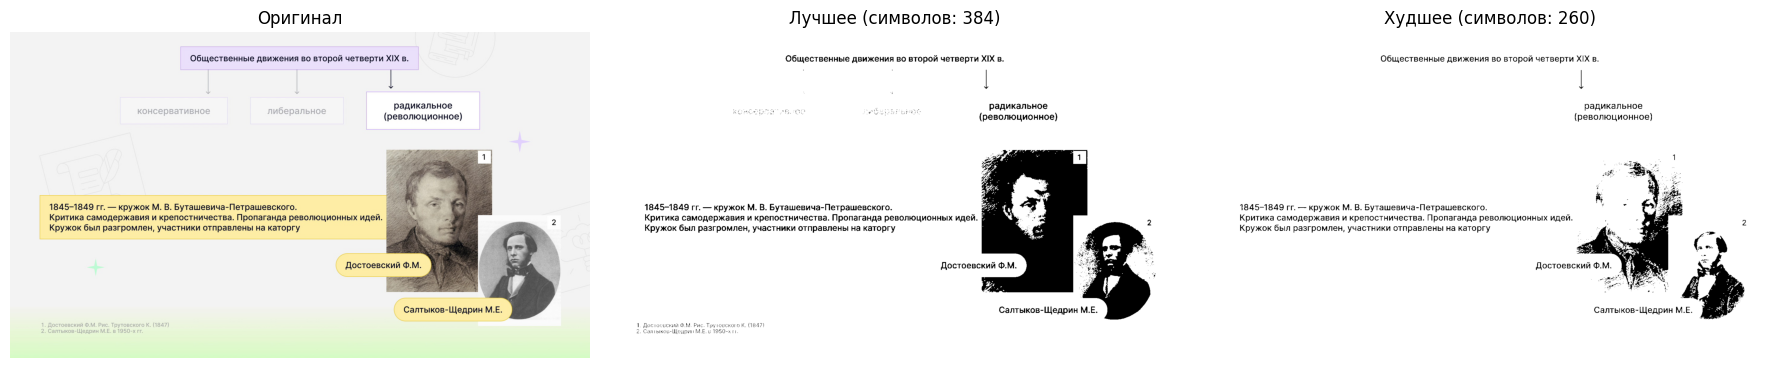

"Лучший текст (символов: 384) α: 0.80, β: 40","Худший текст (символов: 260) α: 1.15, β: 106"
"Общественные движения во второй четверти ХИХ в. | радикальное (революционное) 1845-1849 гг. — кружок М. В. Буташевича-Петрашевского. я Критика самодержавия и крепостничества. Пропаганда революционных идей. в Кружок был разгромлен, участники отправлены на каторгу Достоевский Ф.М. Салтыков-Щедрин М.Е. Ф.М. Рис. Трутооского К, (18471 Щедрин М.Е, 5 1950-х 1","Общественные движения во второй четверти ХХ в. | радикальное (революционное) 1845-1849 гг. — кружок М. В. Буташевича-Петрашевского. Критика самодержавия и крепостничества. Пропаганда революционных идей. Кружок был разгромлен, участники отправлены на каторгу"


  0:01:25.308  ₀⡄₃₉⡄₃₀.₇₅₈ keyframe_45.jpg обработан

🔎 Обработка: keyframe_47.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
384 384 384 384 384 384 351 351 319 309 309 309 288 288 309 309 288 288 309 313 309 288 309 288 alpha=0.80
371 371 297 309 309 309 288 288 309 311 288 290 288 309 313 309 288 309 309 288 292 308 288 308 alpha=0.87
309 288 288 309 309 311 290 288 309 309 288 309 288 309 288 288 309 308 288 289 287 287 287 287 alpha=0.94
311 290 288 288 288 313 309 288 288 309 288 288 313 308 288 309 308 287 287 287 287 287 287 287 alpha=1.01
309 309 288 288 288 309 288 288 313 312 288 288 308 287 287 287 287 287 287 287 287 315 315 308 alpha=1.08
309 309 288 313 312 308 288 288 287 287 287 287 287 287 287 287 287 287 315 287 308 318 260 287 alpha=1.15
288 312 288 309 287 287 287 287 287 287 287 287 287 287 320 287 308 308 310

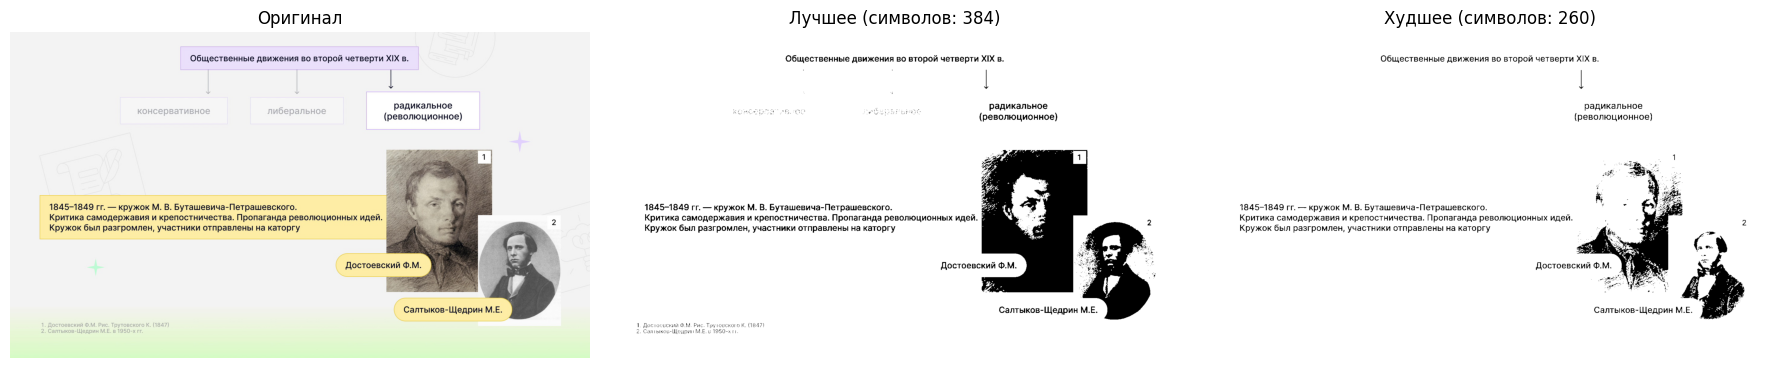

"Лучший текст (символов: 384) α: 0.80, β: 40","Худший текст (символов: 260) α: 1.15, β: 106"
"Общественные движения во второй четверти ХИХ в. | радикальное (революционное) 1845-1849 гг. — кружок М. В. Буташевича-Петрашевского. я Критика самодержавия и крепостничества. Пропаганда революционных идей. в Кружок был разгромлен, участники отправлены на каторгу Достоевский Ф.М. Салтыков-Щедрин М.Е. Ф.М. Рис. Трутооского К, (18471 Щедрин М.Е, 5 1950-х 1","Общественные движения во второй четверти ХХ в. | радикальное (революционное) 1845-1849 гг. — кружок М. В. Буташевича-Петрашевского. Критика самодержавия и крепостничества. Пропаганда революционных идей. Кружок был разгромлен, участники отправлены на каторгу"


  0:01:25.450  ₀⡄₄₀⡄₅₆.₂₀₈ keyframe_47.jpg обработан

🔎 Обработка: keyframe_48.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
421 421 421 421 421 421 421 421 421 421 421 421 421 420 421 420 420 420 420 420 420 420 420 420 alpha=0.80
421 421 421 421 421 421 421 420 421 421 420 420 420 420 420 420 420 420 420 420 420 420 420 420 alpha=0.87
421 421 420 420 421 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 alpha=0.94
420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 alpha=1.01
420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 alpha=1.08
420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 alpha=1.15
420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420 420

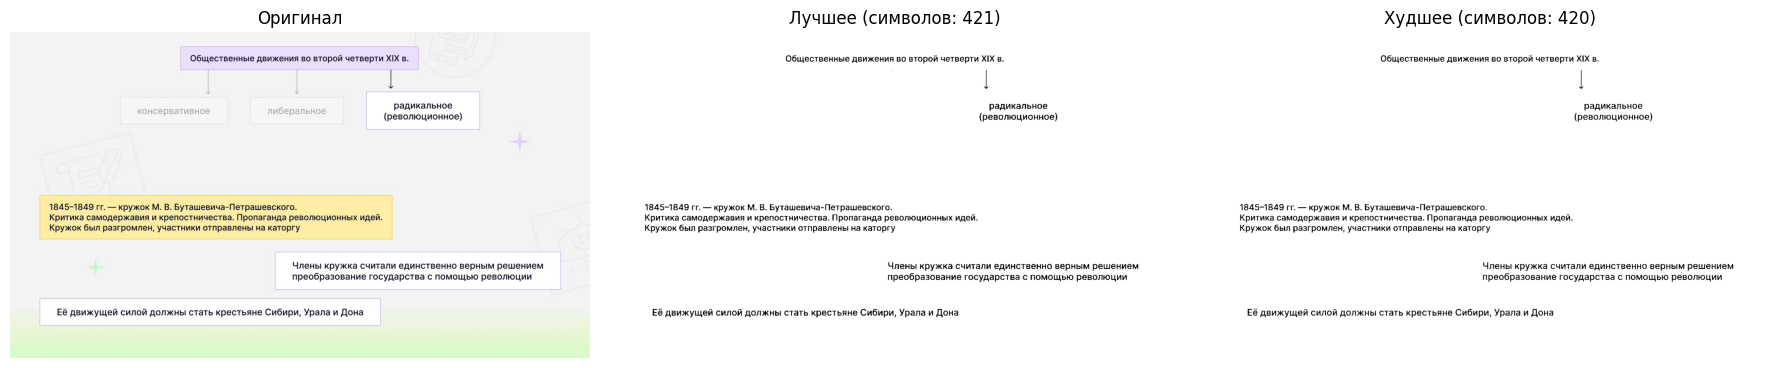

"Лучший текст (символов: 421) α: 0.80, β: 40","Худший текст (символов: 420) α: 0.80, β: 79"
"Общественные движения во второй четверти ХИХ в. | радикальное (революционное) 1845-1849 гг. — кружок М. В. Буташевича-Петрашевского. Критика самодержавия и крепостничества. Пропаганда революционных идей. Кружок был разгромлен, участники отправлены на каторгу Члены кружка считали единственно верным решением преобразование государства с помощью революции Её движущей силой должны стать крестьяне Сибири, Урала и Дона","Общественные движения во второй четверти ХХ в. | радикальное {революционное} 1845-1849 гг. — кружок М. В. Буташевича-Петрашевского. Критика самодержавия и крепостничества. Пропаганда революционных идей. Кружок был разгромлен, участники отправлены на каторгу Члены кружка считали единственно верным решением преобразование государства с помощью революции Её движущей силой должны стать крестьяне Сибири, Урала и Дона"


  0:01:42.811  ₀⡄₄₂⡄₃₉.₀₂₀ keyframe_48.jpg обработан

🔎 Обработка: keyframe_49.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
266 266 266 266 266 266 266 266 266 266 261 266 266 266 266 266 266 266 266 266 266 266 266 266 alpha=0.80
266 266 266 266 266 266 266 266 266 266 266 266 266 266 266 266 266 266 265 266 265 265 265 265 alpha=0.87
266 266 266 266 266 266 266 266 266 266 266 266 266 265 265 265 265 265 265 265 265 265 265 265 alpha=0.94
266 266 266 266 266 266 266 266 266 266 265 265 265 265 265 265 265 265 286 265 265 265 265 308 alpha=1.01
266 266 266 266 266 266 265 265 265 265 265 265 265 265 286 286 265 265 265 271 265 265 265 265 alpha=1.08
266 265 265 265 265 265 265 265 265 265 265 265 265 265 265 265 308 265 265 265 265 278 267 265 alpha=1.15
265 267 267 265 265 265 265 286 265 265 265 265 271 306 265 265 265 281 278

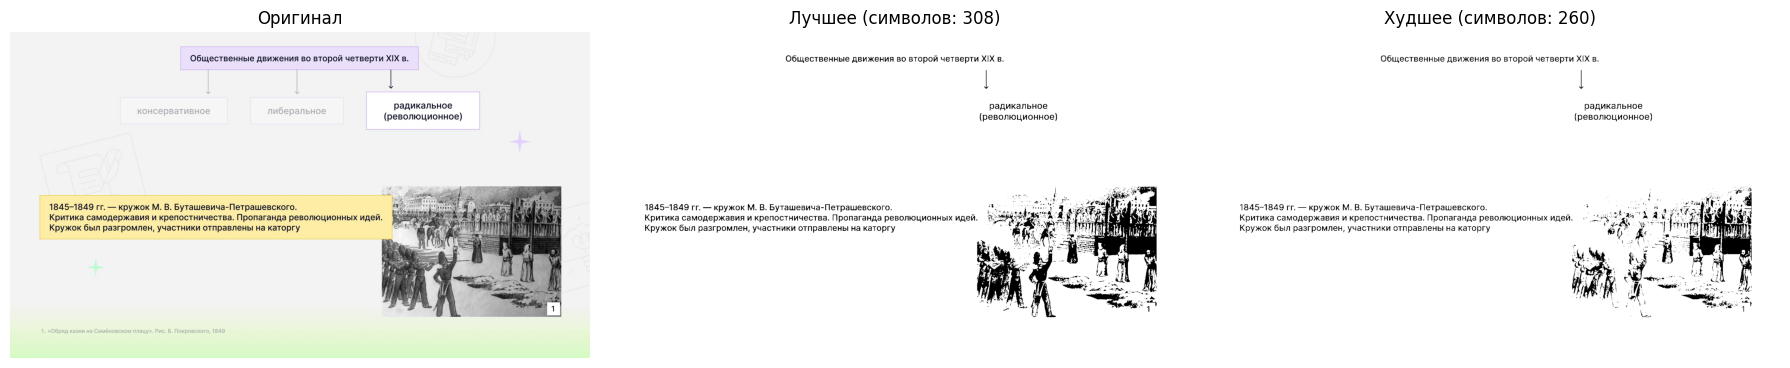

"Лучший текст (символов: 308) α: 1.01, β: 109","Худший текст (символов: 260) α: 1.36, β: 106"
"Общественные движения во второй четверти ХХ в. | радикальное {революционное} 1845-1849 гг. — кружок М. В. Буташевича-Петрашевского. ; о . $ в Критика самодержавия и крепостничества. Пропаганда революционных идей. * ет ЕЙ К ` Кружок был разгромлен, участники отправлены на каторгу я | Н, г Ка РЫВЕИНА","Общественные движения во второй четверти ХХ в. | радикальное (революционное) 1845-1849 гг. — кружок М. В. Буташевича-Петрашевского. Критика самодержавия и крепостничества. Пропаганда революционных идей. Кружок был разгромлен, участники отправлены на каторгу"


  0:01:24.221  ₀⡄₄₄⡄₀₃.₂₄₁ keyframe_49.jpg обработан

🔎 Обработка: keyframe_50.jpg
    β
 40  43  46  49  52  55  58  61  64  67  70  73  76  79  82  85  88  91  94  97 100 103 106 109 
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 alpha=0.80
33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 alpha=0.87
33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 alpha=0.94
33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 alpha=1.01
33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 alpha=1.08
33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 alpha=1.15
33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 alpha=1.22
33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 alpha=1.29
33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 alpha=1.

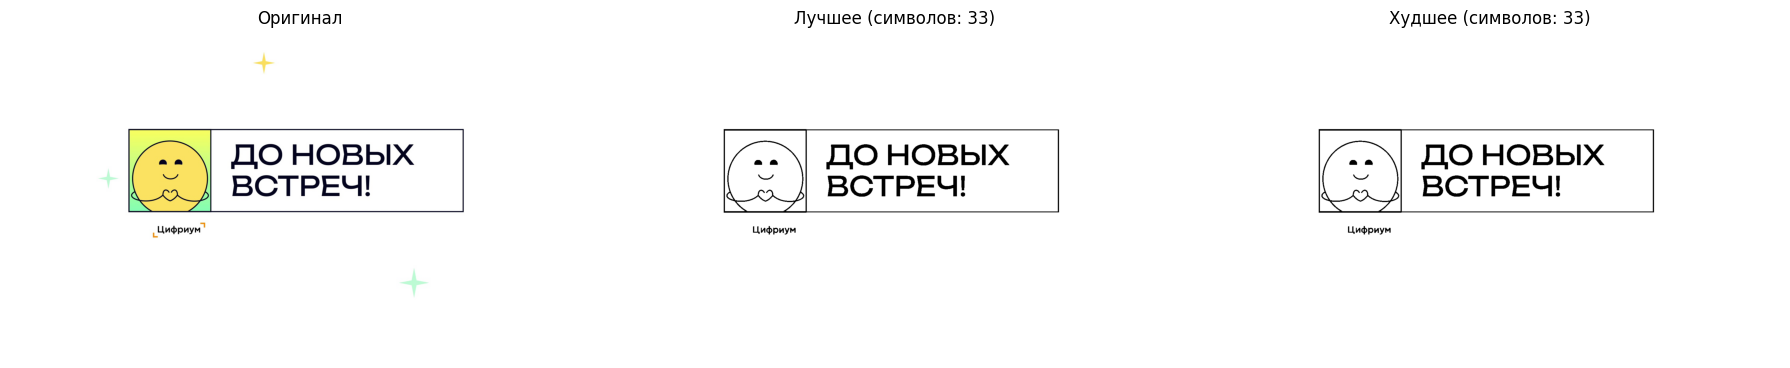

"Лучший текст (символов: 33) α: 0.80, β: 40","Худший текст (символов: 33) α: 0.80, β: 43"
(2) ДО Новых \ 1 ВСТРЕЧ! Цифриум,(2) ДО Новых \ 1 ВСТРЕЧ! Цифриум


  0:00:44.690  ₀⡄₄₄⡄₄₇.₉₃₂ keyframe_50.jpg обработан
         0:00  ₀⡄₄₄⡄₄₇.₉₃₂ 🏁 Готово


datetime.datetime(2025, 4, 27, 9, 13, 5, 761544)

In [6]:
import os
import cv2
import numpy as np
import glob
import pytesseract
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import pandas as pd


# Путь к изображениям
folder = r'results/keyframes'
files = glob.glob(os.path.join(folder, "*.jpg"))


def process_trace_text(original_cv2, alpha=1.0, beta=0):
    # 1. Изменяем контрастность и яркость
    adjusted = cv2.convertScaleAbs(original_cv2, alpha=alpha, beta=beta)

    # 2. Переводим в ч/б
    gray = cv2.cvtColor(adjusted, cv2.COLOR_BGR2GRAY)

    # 3. Применяем пороговую фильтрацию для выделения текста
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # 4. (дополнительно можно морфологию) — небольшая очистка фона
    kernel = np.ones((2, 2), np.uint8)
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # 5. Конвертация обратно для pytesseract
    final_pil = Image.fromarray(cleaned)

    # 6. Распознавание текста
    text = pytesseract.image_to_string(final_pil, lang='rus')

    # 7. Оценка результата
    score = len(text.strip())  # Количество символов

    return text, score, cleaned

# Функция обработки одного изображения
def ocr_alpha_beta(image_path):
    original_pil = Image.open(image_path).convert("RGB")
    original_cv2 = cv2.cvtColor(np.array(original_pil), cv2.COLOR_RGB2BGR)

    best_score = -1
    worst_score = 1e9
    best_params = None
    worst_params = None
    best_text = ""
    worst_text = ""
    _firstscore = None

    
    # alpha_values = np.arange(0.8, 1.6, 0.2)
    # beta_values = np.arange(40, 111, 5)

    alpha_values = np.arange(0.8, 1.6, 0.07)
    beta_values = np.arange(40, 111, 3)


    print(f"\n🔎 Обработка: {os.path.basename(image_path)}")
    print(f"{'β':>5}")
    
    for beta in beta_values:
        print(f"{beta:>3} ", end='')
    print("\n" + "--- " * len(beta_values))

    for alpha in alpha_values:
        print(f"{alpha:>4.2f}", end=' ')
        for beta in beta_values:

            # adjusted = cv2.convertScaleAbs(original_cv2, alpha=alpha, beta=beta)
            # adjusted_pil = Image.fromarray(cv2.cvtColor(adjusted, cv2.COLOR_BGR2RGB))
            # text = pytesseract.image_to_string(adjusted_pil, lang='rus')
            # score = len(text.strip())  # Количество символов в распознанном тексте


            text, score, adjusted = process_trace_text(original_cv2, alpha, beta)


            _firstscore = _firstscore if _firstscore else score
    
            
            if score > best_score:
                best_score = score
                best_img = adjusted.copy()
                best_params = (alpha, beta)
                best_text = text.strip()
                
                # _score =  gradient_bg((score-_firstscore)/2, score)
                _score = f'{ps.BBLUE}{ps.WHITE}{score} {ps._}'

            elif score < worst_score:
                worst_score = score
                worst_img = adjusted.copy()
                worst_params = (alpha, beta)
                worst_text = text.strip()
                
                # _score =  gradient_bg((score-_firstscore)/2, score)
                _score = f'{ps.BDRED}{ps.WHITE}{score} {ps._}'
            else: 
                _score =  gradient_bg((score-_firstscore)/2, score) + ' '
            
            print (f'{_score:>3}', end='')


        print (f'alpha={alpha:1.2f}')

    # print("\n✅ ЛУЧШИЕ ПАРАМЕТРЫ:")
    # print(f"Alpha: {best_params[0]:.2f}, Beta: {best_params[1]}, Символов: {best_score}")
    # print("✅ ХУДШИЕ ПАРАМЕТРЫ:")
    # print(f"Alpha: {worst_params[0]:.2f}, Beta: {worst_params[1]}, Символов: {worst_score}")

    # Визуализация
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    axs[0].imshow(cv2.cvtColor(original_cv2, cv2.COLOR_BGR2RGB))
    axs[0].set_title("Оригинал")
    axs[0].axis('off')

    axs[1].imshow(cv2.cvtColor(best_img, cv2.COLOR_BGR2RGB))
    axs[1].set_title(f"Лучшее (символов: {best_score})")
    axs[1].axis('off')

    axs[2].imshow(cv2.cvtColor(worst_img, cv2.COLOR_BGR2RGB))
    axs[2].set_title(f"Худшее (символов: {worst_score})")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

    _b_text = best_text.replace("\n", ' ')
    _w_text = worst_text.replace("\n", ' ')
    
    html_content = f'''
    <table border="1" style="border-collapse: collapse; width: 100%;">
        <tr style="background-color: #eee;">
            <th>Лучший текст (символов: {best_score}) α: {best_params[0]:.2f}, β: {best_params[1]}</th>
            <th>Худший текст (символов: {worst_score}) α: {worst_params[0]:.2f}, β: {worst_params[1]}</th>
        </tr>
        <tr>
            <td style="vertical-align:top; padding: 10px;">{_b_text}</td>
            <td style="vertical-align:top; padding: 10px;">{_w_text}</td>
        </tr>
    </table>
    '''
    display(HTML(html_content))

    

    return {
        "best_score": best_score,
        "worst_score": worst_score,
        "best_params": best_params,
        "worst_params": worst_params,
        "best_text": best_text,
        "worst_text": worst_text
    }

# Обработка всех файлов
tg(f"🚩 Найдено файлов: {len(files)}")
tm(f"🚩 Найдено файлов: {len(files)}")

for path in files:
    result = ocr_alpha_beta(path)
    tm(f"{os.path.basename(path)} обработан")
    tg(f"{os.path.basename(path)} обработан", tags=str(result))

tm("🏁 Готово")
